In [1]:
## 2026.09.03 Copy from Xenium_brca → CODEX GBM
## Three-head Hist2Pheno (L2 / L12 / L1), same as HCC; Xenium scale like lung.
##
## Paths:
##   data/CODEX/GBM/Cases/{P174511_Initial,P179161_Recurrent}/project_all_UNI/
## Feature extraction:
##   SAMPLE=P174511_Initial bash code/CODEX_gbm/demo_GT_feature_extraction_Single.sh gt
##   SAMPLE=P174511_Initial bash code/CODEX_gbm/demo_GT_feature_extraction_Single.sh stardist
##
## Preprocess CSVs (run before this notebook):
##   python code/CODEX_gbm/match_codex_cells_with_pixel.py --sample P174511_Initial
##   writes:
##     Cases/{sample}/{sample}_cells_with_pixel.csv
##     Cases/{sample}/{sample}_cells_matched_by_stardist.csv
## This notebook generates matched h5ad once:
##   {sample}_matched_features.h5ad
##   {sample}_matched_features_stardist.h5ad
##
## CLI twin:
##   python -u code/CODEX_gbm/GBM_train_validate_cv_UNIlabel.py --sample P174511_Initial
##   python -u code/CODEX_gbm/GBM_train_validate_cv_UNIlabel.py --mode cross-dataset
##
## Spatial context defaults: use_spatial_context=True, spatial_k=8, spatial_mode='mean'

## 2026.09.08 update the cell lables in three levels 

## Set env

In [2]:
import os
import sys
import importlib
import pandas as pd
import numpy as np
from pathlib import Path

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg/'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

_gbm_dir = f'{path}Hist2Pheno/code/CODEX_gbm/'
if _gbm_dir not in sys.path:
    sys.path.insert(0, _gbm_dir)

# Unified plotting selector (avoids repeating per-tier scheme strings).
PAN_ORGAN = "codex_gbm"
# Choose GPU (must be before any torch import)
os.environ.setdefault("NCRT_CUDA_DEVICE", "0")
# Runtime env (GPU pin + tmpdir) before torch import.
from runtime_env import configure_notebook_runtime
_runtime = configure_notebook_runtime()
NCRT_PHYSICAL_GPU = _runtime["physical_gpu"]


CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


## Load Hist2Pheno

In [3]:

## Import (or reload) base module
# Do NOT `import model` — that binds the name ``model`` to the *module* and will shadow
# your trained ``torch.nn.Module`` after ``globals().update(LP)`` when this cell is re-run.
import base
import plot
import model as model_pkg
## Impost：Force reload base.py
importlib.reload(base)
importlib.reload(plot)
importlib.reload(model_pkg)

import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)
from uni_label_cv_helpers import (
    ensure_lp_extra_insample_preds,
    stardist_head_preds,
    plot_he_confusion_matrices,
    plot_he_spatial_extra_tiers,
    plot_he_f1_extra_tiers,
    build_insample_tier_metrics,
    plot_stardist_spatial_extra,
    plot_stardist_acc_extra,
    plot_stardist_confusion_extra,
    plot_stardist_f1_extra,
    plot_stardist_roc_extra,
)

## Re-import the function (otherwise, still be old_version).
from base import (
    evaluate,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    match_hist2cell_h5ad,
    load_matched_h5ad,
    prepare_data_from_matched_h5ad,
    adata_X_to_dense,
    load_matched_features_bundle,
    encode_labels_with_class_names,
    save_hce_validation_metrics,
    collect_hce_tier_metrics_extras,
    split_train_test,
    build_spatial_neighbor_index,
    first_pth_tensor
    
)

from plot import (
    plot_celltype_spatial_distribution,
    plot_confusion_matrix,
    plot_level1_spatial_distribution,
    plot_tier_spatial_distribution,
    plot_per_class_f1,
    plot_per_class_accuracy,
    plot_level1_accuracy_from_level2_predictions,
    mlp_collect_softmax_probs,
    mlp_collect_five_head_softmax_probs,
    plot_multiclass_roc_curves,
    plot_level1_roc_from_level2_scores,
    plot_level1_f1_from_level2_predictions,
    plot_level1_accuracy_from_level1_head,
    plot_level1_f1_from_level1_head,
    plot_level1_roc_from_level1_head
)

from model import (
    get_select4_best_checkpoint_path,
    sync_best_mlp_from_logo_fold,
    load_model_for_predict,
    run_stratified_kfold_cv_with_insample_report,
    predict_all_label_heads,
)

print("Successfully reloaded functions from base.py")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')} (physical GPU {NCRT_PHYSICAL_GPU})")


Successfully reloaded functions from base.py
CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


## Define dataset

In [4]:
## Set the path — CODEX GBM (P174511_Initial / P179161_Recurrent)
from gbm_paths import stardist_csv_path as gbm_stardist_csv_path

GBM_ROOT = f'{path}Hist2Pheno/data/CODEX/GBM'
CASES_ROOT = f'{GBM_ROOT}/Cases'
STARDIST_ROOT = os.environ.get(
    'STARDIST_ROOT',
    f'{GBM_ROOT}/WangLab/StarDist_Segment',
)
os.chdir(CASES_ROOT)

# Sample key; change to 'rep2' to switch replicates
therapy_data = 'P174511_Initial'
therapy_model = 'project_all_UNI'  # Cases/{therapy_data}/project_all_UNI/
save_result = 'result'
stardist_data = 'StarDist_Segment'

# Spatial context (lung / HCC CLI defaults): fuse kNN neighbor UNI embeddings before MLP
use_spatial_context = True
spatial_k = 8
spatial_mode = 'mean'  # 'mean' | 'attention'

acq_id = therapy_data  # UNI --dataset sc_{sample} → pth prefix sc_P174511_Initial

SAMPLE_DIR = f'{CASES_ROOT}/{therapy_data}'
MODEL_DIR = f'{SAMPLE_DIR}/{therapy_model}'

# Preprocessed CSV inputs (from match_codex_cells_with_pixel.py)
cell_coords_path = f'{SAMPLE_DIR}/{therapy_data}_cells_with_pixel.csv'
celltype_pixel_stardist_path = f'{SAMPLE_DIR}/{therapy_data}_cells_matched_by_stardist.csv'
stardist_raw_path = str(gbm_stardist_csv_path(therapy_data, STARDIST_ROOT))

print(f'therapy_data (sample)     = {therapy_data}')
print(f'acq_id (UNI prefix)       = {acq_id}')
print(f'MODEL_DIR                 = {MODEL_DIR}')
print(f'STARDIST_ROOT             = {STARDIST_ROOT}')
print(f'spatial_context           = {use_spatial_context} (k={spatial_k}, mode={spatial_mode!r})')
print(f'GT cells CSV exists       = {Path(cell_coords_path).is_file()}  → {cell_coords_path}')
print(f'StarDist-matched CSV      = {Path(celltype_pixel_stardist_path).is_file()}  → {celltype_pixel_stardist_path}')
print(f'StarDist_Segment CSV      = {Path(stardist_raw_path).is_file()}  → {stardist_raw_path}')

## Feature extraction (from repo root Hist2Pheno):
##   SAMPLE=P174511_Initial bash code/CODEX_gbm/demo_GT_feature_extraction_Single.sh gt
##   SAMPLE=P174511_Initial bash code/CODEX_gbm/demo_GT_feature_extraction_Single.sh stardist
##
## Preprocess cell tables (run once per sample before this notebook):
##   python code/CODEX_gbm/match_codex_cells_with_pixel.py --sample P174511_Initial


therapy_data (sample)     = P174511_Initial
acq_id (UNI prefix)       = P174511_Initial
MODEL_DIR                 = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI
STARDIST_ROOT             = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/WangLab/StarDist_Segment
spatial_context           = True (k=8, mode='mean')
GT cells CSV exists       = True  → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_cells_with_pixel.csv
StarDist-matched CSV      = True  → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_cells_matched_by_stardist.csv
StarDist_Segment CSV      = True  → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/WangLab/StarDist_Segment/174511-2-3/174511-2-3_Float_prob0.01_nms_0.3.csv


In [5]:
## Result figures: name → filename under .../{therapy_model}/result
from uni_label_cv_helpers import RESULT_FIG, make_result_fig

# Canonical GBM layout: Cases/{sample}/{model}/result/
SELECT4_ROOT = CASES_ROOT
_result_dir = f'{SELECT4_ROOT}/{therapy_data}/{therapy_model}/{save_result}'
FIG = RESULT_FIG
result_fig, _result_dir_path = make_result_fig(SELECT4_ROOT, therapy_data, therapy_model, save_result)
BEST_MLP_PATH = f'{MODEL_DIR}/best_mlp_gpu.pt'
print('result_dir =', _result_dir_path)
print('best_mlp  =', BEST_MLP_PATH)


result_dir = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result
best_mlp  = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/best_mlp_gpu.pt


In [6]:
## CUDA/CPU sanity check + reproducibility (delegated to Hist2Pheno_pkg)
from torch_runtime import configure_torch_runtime

SEED = 42
TORCH_CUDA_INDEX = 0

_runtime = configure_torch_runtime(seed=SEED, torch_cuda_index=TORCH_CUDA_INDEX)

# Keep the same variable names used downstream.
device = _runtime.device
amp_scaler = _runtime.amp_scaler
CUDA_DEVICE_INDEX = _runtime.cuda_device_index
PHYSICAL_GPU = _runtime.physical_gpu


/nobackup2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
CUDA_VISIBLE_DEVICES='0' -> physical GPU(s) '0'
Using physical GPU 0 as logical cuda:0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda:0 | physical GPU 0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
Reproducibility configured with SEED=42


### Load image feature

In [7]:
hist_embedding_dir = Path(f'{MODEL_DIR}/ImgEmbeddings_all/sc_pth_16_16')
print(hist_embedding_dir)
tensor = first_pth_tensor(hist_embedding_dir)


/home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16
Found file: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16/sc_P174511_Initial_23111.555914434524_9195.986050039985.pth
Loaded type: <class 'tuple'>
tensor.shape of the first .pth file: torch.Size([1, 1, 1024])


Example UNI embedding dir for this GBM sample:

`{CASES_ROOT}/{therapy_data}/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16`

e.g. `/home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16`

Each `.pth` is typically `torch.Size([1, 1, 1024])`.


## Cell Type Classification Model

Stratified k-fold CV on one CODEX GBM replicate (P174511_Initial or P179161_Recurrent).
Three-head hierarchy: L2 fine (`final_CT`) / L12 intermediate (`final_sublineage`) / L1 coarse (`final_lineage`).
`Unlabeled` cells are dropped in `match_codex_cells_with_pixel.py` (empty L12/L1 parents).


In [8]:
## Match UNI embeddings → AnnData (.h5ad) for CODEX GBM (three-head hierarchy)
# Excel hierarchy: celltype_level2 (fine / subcluster) → celltype_level1 (intermediate / SN)
# → celltype_level0 (coarse / cell_type)
#
# CSV input is prebuilt by code/CODEX_gbm/match_codex_cells_with_pixel.py:
#   {SAMPLE_DIR}/{therapy_data}_cells_with_pixel.csv
# This cell only builds matched_features.h5ad (generate once; reuse when present).
from gbm_paths import load_gbm_celltype_hierarchy

hierarchy_df = load_gbm_celltype_hierarchy()
print(hierarchy_df.nunique().rename("n_classes").to_string())

# Prefer paths defined in the path-setup cell; fall back if re-run out of order.
cell_coords_path = globals().get(
    'cell_coords_path', f'{SAMPLE_DIR}/{therapy_data}_cells_with_pixel.csv'
)
matched_h5ad_path = f'{SAMPLE_DIR}/{therapy_data}_matched_features.h5ad'
hist_embedding_dir = Path(f'{MODEL_DIR}/ImgEmbeddings_all/sc_pth_16_16')
pth_prefix_gt = f'sc_{acq_id}'

if not Path(cell_coords_path).is_file():
    raise FileNotFoundError(
        f"Missing preprocessed GT table: {cell_coords_path}\n"
        "Run: conda run -n SeededNTM python code/CODEX_gbm/match_codex_cells_with_pixel.py "
        f"--sample {therapy_data}"
    )
print(f'Using preprocessed GT cells: {cell_coords_path}')

# Internal model naming: L2=fine, L12=intermediate, L1=coarse.
column_rename = {
    'final_CT': 'celltype',
    'final_sublineage': 'celltype_level12',
    'final_lineage': 'celltype_level1',
}
match_tolerance = 1.0

# Build matched h5ad once. Set True only after changing hierarchy / embeddings / CSV.
FORCE_REBUILD_MATCHED_H5AD = False
if not Path(matched_h5ad_path).is_file():
    FORCE_REBUILD_MATCHED_H5AD = True
print(f'FORCE_REBUILD_MATCHED_H5AD = {FORCE_REBUILD_MATCHED_H5AD}')

adata = match_hist2cell_h5ad(
    cell_coords_path=cell_coords_path,
    hist_embedding_dir=hist_embedding_dir,
    matched_h5ad_path=matched_h5ad_path,
    coord_cols=('X_pix_HE', 'Y_pix_HE'),
    tolerance=match_tolerance,
    pth_prefix=pth_prefix_gt,
    level1_name='celltype_level1',
    column_rename=column_rename,
    auto_rename=False,
    force_rebuild=FORCE_REBUILD_MATCHED_H5AD,
    obs_columns=base.HCC_H5AD_OBS_COLUMNS,
    cell_id_col='cell_id',
)
print(adata)
print('obs columns:', list(adata.obs.columns))
print('obsm keys:', list(adata.obsm.keys()))


celltype_level2     5
celltype_level1    16
celltype_level0     9
Using preprocessed GT cells: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_cells_with_pixel.csv
FORCE_REBUILD_MATCHED_H5AD = False
  ✓ matched h5ad cache found; loading /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_matched_features.h5ad
  ✓ Loaded h5ad: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_matched_features.h5ad (37,371 cells × 1024 features)
AnnData object with n_obs × n_vars = 37371 × 1024
    obs: 'final_CT', 'final_lineage', 'final_sublineage', 'tma', 'cell_id', 'cell_type', 'subcluster', 'spatial_niche', 'bin_barcode'
    uns: 'cell_coords_path', 'embedding_dim', 'embedding_dir', 'match_rate', 'match_tolerance', 'matched_n_cells', 'pth_prefix', 'raw_n_cells', 'source_csv', 'source_row_count'
    obsm: 'spatial', 'spatial_HE'
obs columns: ['final_CT', 'final_lineage', 'final_subline

In [9]:
# Prep CV arrays for GBM three-head hierarchy.
from sklearn.preprocessing import StandardScaler

cv_data = prepare_data_from_matched_h5ad(
    adata,
    groups=np.arange(adata.n_obs, dtype=np.int64),
    require_niche_heads=False,
)
USE_THREE_HEAD = "y_level12_encoded_f" in cv_data
USE_FIVE_HEAD = False
print(
    "Three-head training (GBM): "
    "L2=final_CT (subcluster), "
    "L12=final_sublineage (spatial_niche), "
    "L1=final_lineage (cell_type)"
)

class_names = cv_data["class_names"]
class_names_level1 = cv_data["class_names_level1"]
class_names_level12 = cv_data["class_names_level12"]
class_names_level3 = class_names_level4 = None
le_level2 = cv_data["le_level2"]
le_level1 = cv_data["le_level1"]

scaler = StandardScaler()
scaler.fit(cv_data["X_f"])
X_coords_plot = cv_data.get("X_coords_f")

# Spatial kNN neighbor index (same defaults as lung / HCC CLI)
spatial_neighbor_index = None
if use_spatial_context:
    if X_coords_plot is None:
        raise ValueError("use_spatial_context=True requires X_coords_f in cv_data / spatial_HE in h5ad.")
    spatial_neighbor_index = build_spatial_neighbor_index(
        np.asarray(X_coords_plot), k_neighbors=spatial_k
    )
    print(
        f"Spatial context: k={spatial_k}, mode={spatial_mode!r}, "
        f"neighbor_index shape={spatial_neighbor_index.shape}"
    )

X = adata_X_to_dense(adata.X)
y = adata.obs["final_CT"].to_numpy()
y_level1 = adata.obs["final_lineage"].to_numpy()
y_level12 = adata.obs["final_sublineage"].to_numpy()
y_level3 = y_level4 = None
X_coords_matched = adata.obsm["spatial_HE"]
matched_features_path = matched_h5ad_path

RUN_RANDOM_TRAIN_TEST_SPLIT = False
result = split_train_test(X, y, y_level1) if RUN_RANDOM_TRAIN_TEST_SPLIT else None



Leave-one-group-out prep (filtered data):
  Samples: 37371, features: 1024
  Level2 classes: 5
  Level1 classes: 6
  Level12 classes: 13
  Coordinates: (37371, 2)
  Groups (for LOGO): 37371 unique
Three-head training (GBM): L2=final_CT (celltype_level2), L12=final_sublineage (celltype_level1), L1=final_lineage (celltype_level0)
Spatial context: k=8, mode='mean', neighbor_index shape=(37371, 8)


In [10]:
# CV fold loaders are built per ablation run; encoded labels come from cv_data (h5ad prep).
loaders = None
train_loader = val_loader = val_loader_eval = None
train_dataset = val_dataset = None
X_train_scaled = y_train_encoded = y_test_encoded = None
y_train_level1_encoded = y_test_level1_encoded = None
y_encoded_f = cv_data["y_encoded_f"]
y_level1_encoded_f = cv_data["y_level1_encoded_f"]


In [11]:
## see matched h5ad
adata = load_matched_h5ad(matched_h5ad_path)
print(adata)
print(adata.obs_names[:3], adata.var_names[:3])
print(adata.obs.columns, list(adata.obsm.keys()))

  ✓ Loaded h5ad: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_matched_features.h5ad (37,371 cells × 1024 features)
AnnData object with n_obs × n_vars = 37371 × 1024
    obs: 'final_CT', 'final_lineage', 'final_sublineage', 'tma', 'cell_id', 'cell_type', 'subcluster', 'spatial_niche', 'bin_barcode'
    uns: 'cell_coords_path', 'embedding_dim', 'embedding_dir', 'match_rate', 'match_tolerance', 'matched_n_cells', 'pth_prefix', 'raw_n_cells', 'source_csv', 'source_row_count'
    obsm: 'spatial', 'spatial_HE'
Index(['ID_100001', 'ID_100004', 'ID_100005'], dtype='object', name='cell_id') Index(['1', '2', '3'], dtype='object')
Index(['final_CT', 'final_lineage', 'final_sublineage', 'tma', 'cell_id',
       'cell_type', 'subcluster', 'spatial_niche', 'bin_barcode'],
      dtype='object') ['spatial', 'spatial_HE']


## MLP classifier

In [12]:
# Ablation: unified HCE weights under stratified_kfold CV
import os
import shutil
import pandas as pd

KFOLD_RESUME_FROM_CHECKPOINTS = True  # GBM first run: train; set True to reuse fold ckpts


AB_PATIENCE = 10
AB_MAX_EPOCHS = 50
AB_HIDDEN_DIMS = (1024, 512, 256)    # Model default
AB_CV_K = 5
AB_STRATIFY_TARGET = "level2"  # L2 = subcluster; Mac_SEPP1 has two L1 parents

ABLATION_CONFIGS = [
    # {"tag": "B_equal", "hce_w1": 1.0, "hce_w2": 1.0, "hce_w12": 1.0},
    # {"tag": "C_emph_L1", "hce_w1": 2.0, "hce_w2": 1.0, "hce_w12": 1.0},
    {
        "tag": "D_emph_L2_spatial" if use_spatial_context else "D_emph_L2",
        "hce_w1": 1.0,    # celltype_level0（coarse / final_lineage）的 CE
        "hce_w2": 2.0,    # celltype_level2（fine / final_CT）的 CE
        "hce_w12": 1.0,   # level2 概率聚合到 level0 后的 mapping NLL
        "hce_w_l12head": 1.0,    # celltype_level1（intermediate / final_sublineage）的 CE
    },
    # {"tag": "E_emph_agg", "hce_w1": 1.0, "hce_w2": 1.0, "hce_w12": 2.0},
]

ablation_runs = {}
rows = []

for cfg in ABLATION_CONFIGS:
    tag = cfg["tag"]

    ckpt_dir = os.path.join(
        SELECT4_ROOT, therapy_data, therapy_model, "ablation_kfold_ckpts", tag
    )

    print("\n" + "=" * 80)
    print(f"[Ablation][stratified_kfold] Running: {tag}")
    if use_spatial_context:
        print(f"  spatial: k={spatial_k}, mode={spatial_mode!r}")
    print("=" * 80)

    LP_i = run_stratified_kfold_cv_with_insample_report(
        device=device,
        cv_data=cv_data,
        scaler=scaler,
        class_names=class_names,
        evaluate=evaluate,
        path=path,
        therapy_data=therapy_data,
        therapy_model=therapy_model,
        hce_w1=cfg["hce_w1"],
        hce_w2=cfg["hce_w2"],
        hce_w12=cfg["hce_w12"],
        hce_w_l12head=cfg.get("hce_w_l12head", 1.0),
        cv_selection_metric="three_tier_auc_sum",
        val_selection_metric="three_tier_auc_sum",
        n_splits=AB_CV_K,
        stratify_target=AB_STRATIFY_TARGET,
        patience=AB_PATIENCE,
        max_epochs=AB_MAX_EPOCHS,
        loader_kwargs={"seed": SEED, "train_balance_sampler": False},
        resume_from_checkpoints=KFOLD_RESUME_FROM_CHECKPOINTS,
        kfold_checkpoint_dir=ckpt_dir,
        hidden_dims=AB_HIDDEN_DIMS,
        use_spatial_context=use_spatial_context,
        spatial_k=spatial_k,
        spatial_mode=spatial_mode,
    )

    ablation_runs[tag] = LP_i
    score_l4 = float(
        LP_i["val_macro_f1"]
        + LP_i["val_weighted_f1"]
        + LP_i["val_level1_macro_f1"]
        + LP_i["val_level1_weighted_f1"]
    )
    rows.append(
        {
            "tag": tag,
            "hce_w1": cfg["hce_w1"],
            "hce_w2": cfg["hce_w2"],
            "hce_w12": cfg["hce_w12"],
            "hidden_dims": str(AB_HIDDEN_DIMS),
            "l2_acc": float(LP_i["val_acc"]),
            "l2_macro_f1": float(LP_i["val_macro_f1"]),
            "l2_weighted_f1": float(LP_i["val_weighted_f1"]),
            "l1_acc": float(LP_i["val_level1_acc"]),
            "l1_macro_f1": float(LP_i["val_level1_macro_f1"]),
            "l1_weighted_f1": float(LP_i["val_level1_weighted_f1"]),
            "best_epoch": int(LP_i["best_epoch"]),
            "l4_kfold_select_score": score_l4,
        }
    )

AB_SUMMARY_DF = (
    pd.DataFrame(rows)
    .sort_values("l4_kfold_select_score", ascending=False)
    .reset_index(drop=True)
)
print("\nAblation summary (sorted by l4_kfold_select_score = L2/L1 macro+weighted):")
display(AB_SUMMARY_DF)

best_tag = AB_SUMMARY_DF.iloc[0]["tag"]
LP = ablation_runs[best_tag]

best_idx = AB_SUMMARY_DF["l4_kfold_select_score"].astype(float).idxmax()
assert AB_SUMMARY_DF.iloc[best_idx]["tag"] == best_tag

best_cfg = next(c for c in ABLATION_CONFIGS if c["tag"] == best_tag)
best_fold = LP["best_fold"]
best_fold_4term_score = float(
    best_fold["l2_macro_f1"]
    + best_fold["l2_weighted_f1"]
    + best_fold["l1_macro_f1"]
    + best_fold["l1_weighted_f1"]
)

print(f"Selected best config by l4_kfold_select_score: {best_tag}")
print(
    "  Best weights: "
    f"hce_w1={best_cfg['hce_w1']}, hce_w2={best_cfg['hce_w2']}, hce_w12={best_cfg['hce_w12']}"
)
print(
    "  Best fold checkpoint in selected config: "
    f"fold={best_fold['fold']}, 4-term score={best_fold_4term_score:.4f}, path={best_fold['checkpoint']}"
)

# Sync best fold → best_mlp_gpu.pt under Select4 (same tree as kfold writes)
BEST_MLP_CHECKPOINT = sync_best_mlp_from_logo_fold(
    path,
    therapy_data,
    therapy_model,
    best_fold["checkpoint"],
    dest_path=BEST_MLP_PATH,  # CODEX GBM: under HE/{therapy_data}/project_all_UNI/
)
print(f"  Synced best_mlp_gpu.pt: {BEST_MLP_CHECKPOINT}")

# For downstream cells
globals().update(LP)
globals()["AB_SUMMARY_DF"] = AB_SUMMARY_DF
globals()["BEST_MLP_CHECKPOINT"] = BEST_MLP_CHECKPOINT
# Prefer neighbor index from trained LP (same row order as cv_data["X_f"])
if LP.get("spatial_neighbor_index") is not None:
    spatial_neighbor_index = LP["spatial_neighbor_index"]
    globals()["spatial_neighbor_index"] = spatial_neighbor_index
globals()["use_spatial_context"] = use_spatial_context
globals()["spatial_k"] = spatial_k
globals()["spatial_mode"] = spatial_mode



[Ablation][stratified_kfold] Running: D_emph_L2_spatial
  spatial: k=8, mode='mean'


Spatial context: k=8, mode='mean', per-sample kNN, neighbor_index shape=(37371, 8)
Train dataset size: 29896
Val dataset size: 7475
Batch size: 1024
Feature dimension: 1024

KFold fold 0: stratify='level2'
  Resume: checkpoint exists, skip training -> /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/ablation_kfold_ckpts/D_emph_L2_spatial/hce_kfold_fold_0.pt
checkpoint_exists=True: loading checkpoint (no training): /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/ablation_kfold_ckpts/D_emph_L2_spatial/hce_kfold_fold_0.pt
Loaded existing checkpoint metrics: accuracy=0.5201, weighted_f1=0.5585, macro_f1=0.3326
Train dataset size: 29897
Val dataset size: 7474
Batch size: 1024
Feature dimension: 1024

KFold fold 1: stratify='level2'
  Resume: checkpoint exists, skip training -> /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/ablation_kfold_ckpts/D_emph_L

,tag,hce_w1,hce_w2,hce_w12,hidden_dims,l2_acc,l2_macro_f1,l2_weighted_f1,l1_acc,l1_macro_f1,l1_weighted_f1,best_epoch,l4_kfold_select_score
0,D_emph_L2_spatial,1.0,2.0,1.0,"(1024, 512, 256)",0.558107,0.331243,0.551037,0.188355,0.085989,0.241548,0,1.209817


Selected best config by l4_kfold_select_score: D_emph_L2_spatial
  Best weights: hce_w1=1.0, hce_w2=2.0, hce_w12=1.0
  Best fold checkpoint in selected config: fold=3, 4-term score=1.6385, path=/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/ablation_kfold_ckpts/D_emph_L2_spatial/hce_kfold_fold_3.pt
sync_best_mlp_from_logo_fold: wrote '/home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/best_mlp_gpu.pt' ← '/nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/ablation_kfold_ckpts/D_emph_L2_spatial/hce_kfold_fold_3.pt'
  Synced best_mlp_gpu.pt: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/best_mlp_gpu.pt


### Note on level-1 predictions in confusion matrices

- `val_preds_level1` is obtained by aggregating L2 softmax probabilities through the hierarchy mapping matrix (mapped L1), **not** the independent L1 head argmax.
- To inspect the L1 head itself, take `logits_l1` from `forward_heads` and argmax (that path is not stored in the current `LP` object by default).



L2 celltype
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/conf_matrix_level2.pdf


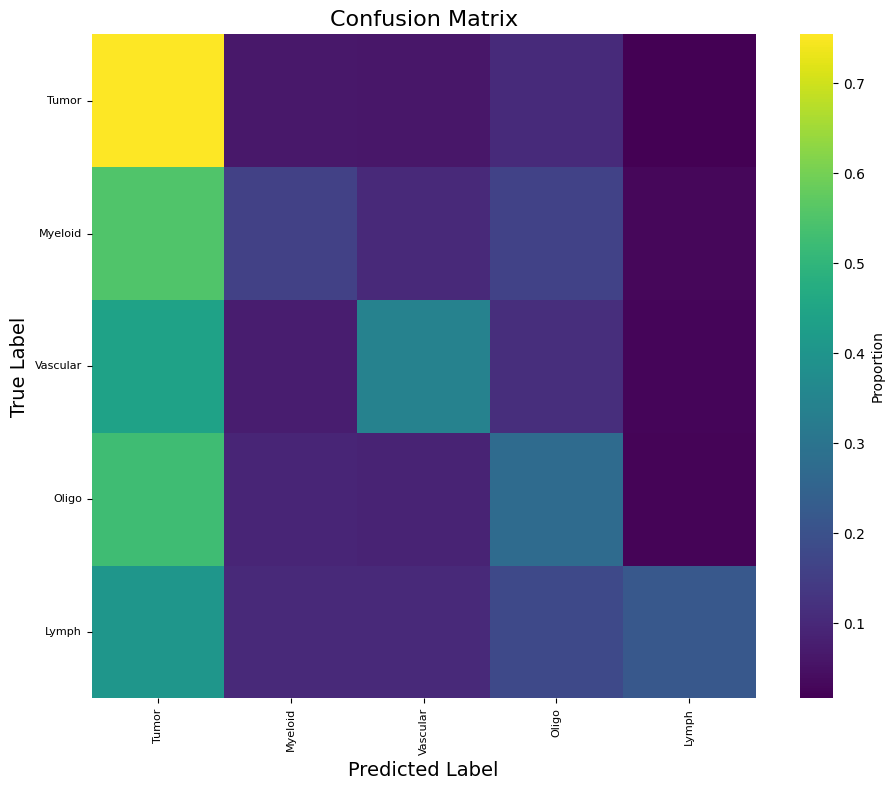


L1 lineage (L2→L1 agg)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/conf_matrix_level1.pdf


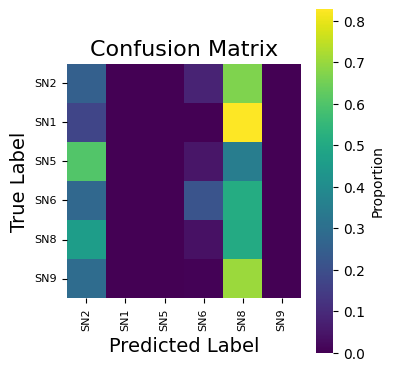


L1 lineage (L1 head)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/conf_matrix_level1_L1head.pdf


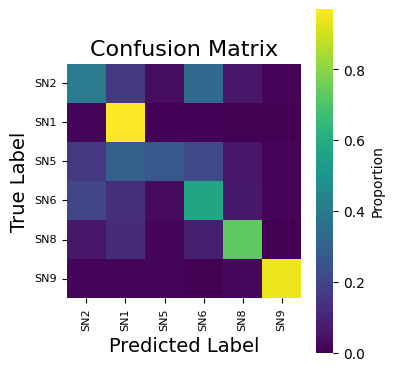


L12 sublineage
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/conf_matrix_level12.pdf


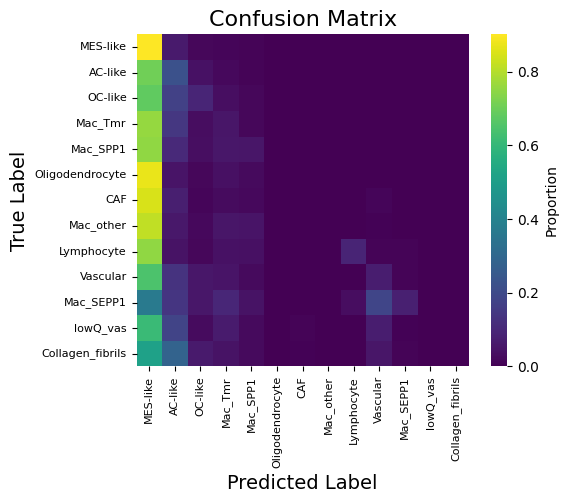

Skip L3 CNiche: no val_preds_level3 (re-run ablation cell after reload model/base)
Skip L4 TNiche: no val_preds_level4 (re-run ablation cell after reload model/base)
L1 agg vs L1 head agreement: 0.1357737282919911


In [13]:
# In-sample confusion matrices for every label tier (best-fold model in LP)
if isinstance(globals().get("LP"), dict) and LP.get("model") is not None:
    ensure_lp_extra_insample_preds(
        LP["model"],
        scaler,
        cv_data,
        device,
        predict_all_label_heads,
        globals(),
        neighbor_index=globals().get("spatial_neighbor_index"),
    )
plot_he_confusion_matrices(plot_confusion_matrix, result_fig, cv_data, globals())


In [14]:
## Save validation metrics: CV fold means + in-sample per tier (L2/L1/L12)
import numpy as np

logo_summary = globals().get("logo_summary")
if logo_summary is None and isinstance(globals().get("LP"), dict):
    logo_summary = LP.get("logo_summary")
if logo_summary is None:
    raise NameError("Run the ablation / CV cell first (globals().update(LP)) to define logo_summary.")

metrics_csv_path = result_fig("validation_internal_metrics")

hce_w1_used = globals().get("hce_w1", 1.0)
hce_w2_used = globals().get("hce_w2", 1.0)
hce_w12_used = globals().get("hce_w12", 2.0)
hce_w_l12head_used = globals().get("hce_w_l12head", 1.0)
hce_w_l3_used = globals().get("hce_w_l3", 1.0)
hce_w_l4_used = globals().get("hce_w_l4", 1.0)
mean_best_epoch = int(round(float(np.mean([f["best_epoch"] for f in logo_summary["folds"]]))))

insample_tiers, _num_classes = build_insample_tier_metrics(globals(), cv_data if "cv_data" in globals() else None)

tier_extra = collect_hce_tier_metrics_extras(
    logo_summary=logo_summary,
    insample=insample_tiers,
    num_classes=_num_classes,
)

_l2_ins = insample_tiers.get("l2") or {}
_l1_ins = insample_tiers.get("l1") or {}

metrics_df, combined_df = save_hce_validation_metrics(
    val_acc=_l2_ins.get("accuracy", float("nan")),
    val_macro_f1=logo_summary["l2_macro_f1_mean"],
    val_weighted_f1=logo_summary["l2_weighted_f1_mean"],
    val_level1_acc=_l1_ins.get("accuracy", float("nan")),
    val_level1_macro_f1=logo_summary["l1_macro_f1_mean"],
    val_level1_weighted_f1=logo_summary["l1_weighted_f1_mean"],
    class_names=class_names if "class_names" in globals() else None,
    class_names_level1=class_names_level1 if "class_names_level1" in globals() else None,
    best_epoch=mean_best_epoch,
    hce_lambda=None,
    hce_w1=hce_w1_used,
    hce_w2=hce_w2_used,
    hce_w12=hce_w12_used,
    hce_w_l12head=hce_w_l12head_used,
    hce_w_l3=hce_w_l3_used,
    hce_w_l4=hce_w_l4_used,
    therapy_data=f"{therapy_data}_kfold_CV",
    metrics_csv_path=metrics_csv_path,
    extra_metrics=tier_extra,
)

print("\nPer-tier columns in CSV (cv_* = fold mean, insample_* = all cells, best-fold model):")
_tier_cols = [c for c in combined_df.columns if c.startswith(("cv_", "insample_", "num_"))]
print(combined_df[_tier_cols].tail(1).T)


Current run metrics:
             timestamp              therapy_data  best_epoch hce_lambda  \
0  2026-09-08 23:53:22  P174511_Initial_kfold_CV           0       None   

   hce_w1  hce_w2  hce_w12  hce_w_l12head  hce_w_l3  hce_w_l4  ...  \
0     1.0     2.0      1.0            1.0       1.0       1.0  ...   

   insample_l1_macro_f1  insample_l1_weighted_f1  insample_l1_head_accuracy  \
0              0.085989                 0.241548                   0.482754   

   insample_l1_head_macro_f1  insample_l1_head_weighted_f1  \
0                   0.427714                      0.528379   

   insample_l12_accuracy  insample_l12_macro_f1  insample_l12_weighted_f1  \
0               0.367718               0.118238                  0.265735   

   num_l1_head_classes  num_l12_classes  
0                    6               13  

[1 rows x 56 columns]

Saved comparison table to: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/validation_intern

Visualizing per-class performance...
  ✓ Computed metrics for 5 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/f1_perclass_level2.pdf


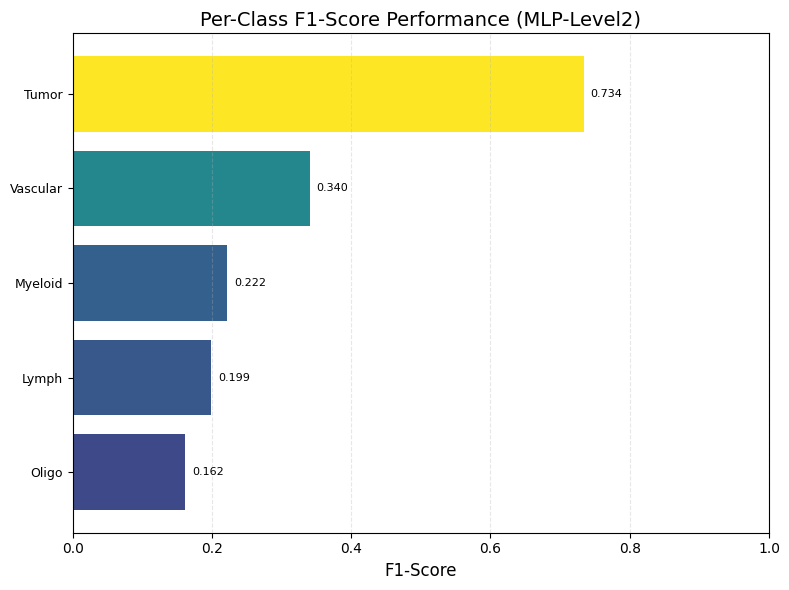


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 5
  Actual classes in test set: 5
  Feature dimension: 1024
  Model parameters: 2,765,080
  Best epoch: 0
  Test Accuracy: 0.5581
  Test Macro F1: 0.3312
  Test Weighted F1: 0.5510
Visualizing per-class performance...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/f1_perclass_level1.pdf


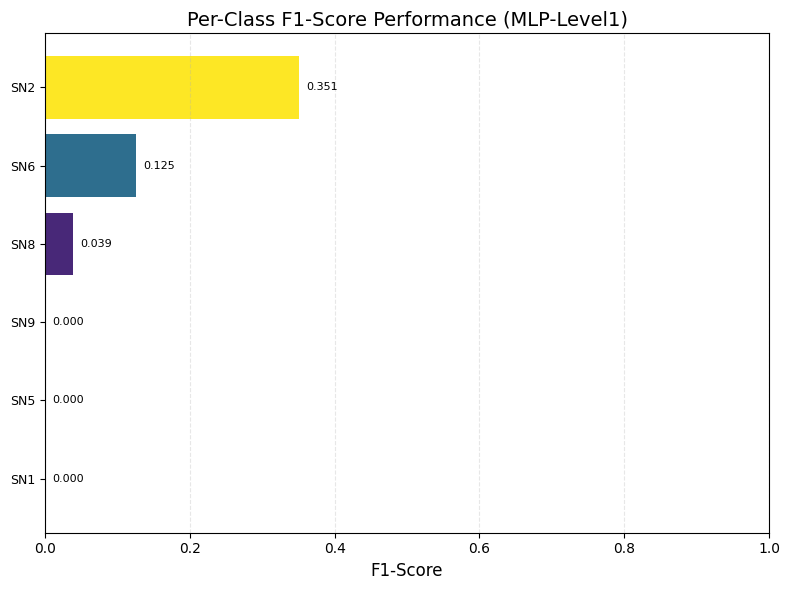


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Feature dimension: 1024
  Model parameters: 2,765,080
  Best epoch: 0
  Test Accuracy: 0.1884
  Test Macro F1: 0.0860
  Test Weighted F1: 0.2415
Visualizing per-class performance...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/f1_perclass_level1_L1head.pdf


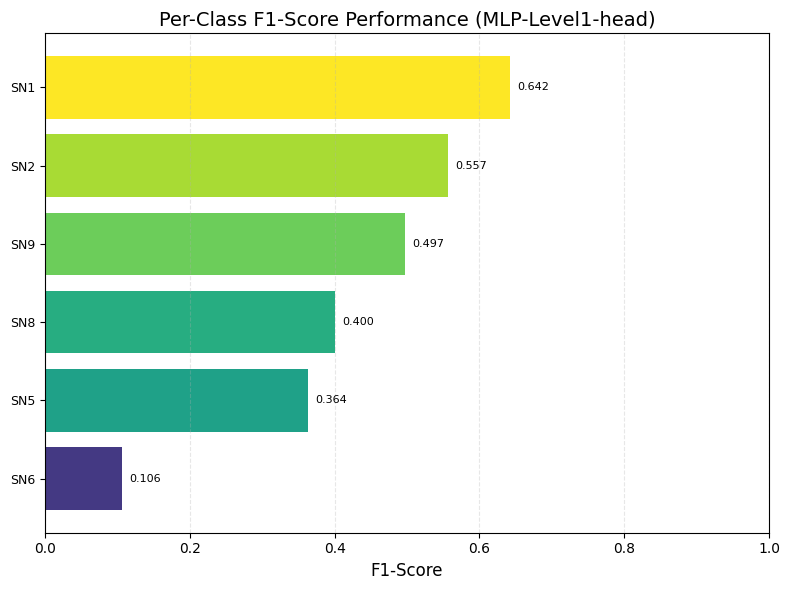


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Feature dimension: 1024
  Model parameters: 2,765,080
  Best epoch: 0
  Test Accuracy: 0.1884
  Test Macro F1: 0.0860
  Test Weighted F1: 0.2415

L12 sublineage
Visualizing per-class performance...
  ✓ Computed metrics for 13 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/f1_perclass_level12.pdf


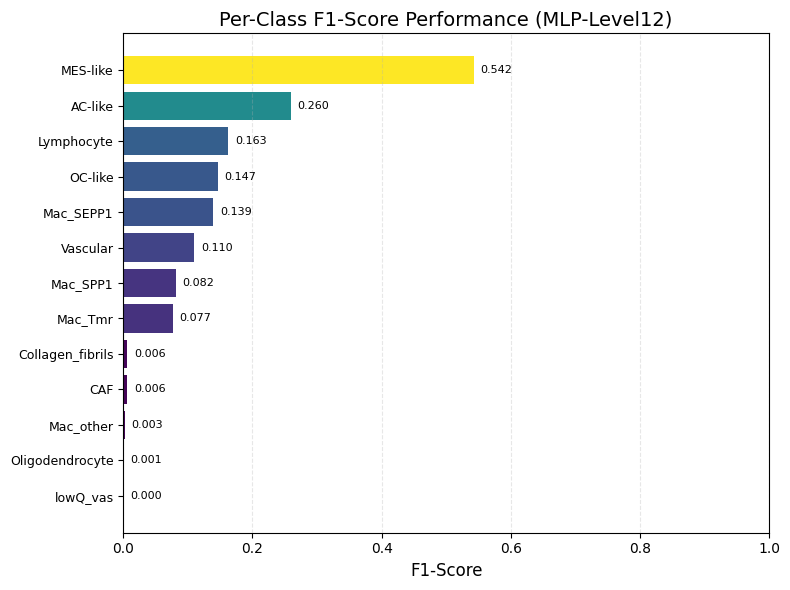


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 13
  Actual classes in test set: 13
  Feature dimension: 1024
  Model parameters: 2,765,080
  Best epoch: 0
  Test Accuracy: 0.3677
  Test Macro F1: 0.1182
  Test Weighted F1: 0.2657
Skip L3 CNiche per-class F1: no val_preds_level3
Skip L4 TNiche per-class F1: no val_preds_level4


In [15]:
# Per-class F1 for level2
metrics_df_level2 = plot_per_class_f1(
    val_labels,
    val_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_acc,
    test_macro_f1=val_macro_f1,
    test_weighted_f1=val_weighted_f1,
    model_name="MLP-Level2",
    y_sort_by="f1_asc",
    save_path=result_fig("f1_perclass_level2"),
)

metrics_df_level1 = plot_per_class_f1(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_level1_acc,
    test_macro_f1=val_level1_macro_f1,
    test_weighted_f1=val_level1_weighted_f1,
    model_name="MLP-Level1",
    y_sort_by="f1_asc",
    save_path=result_fig("f1_perclass_level1"),
)

if globals().get("val_preds_level1_head") is not None:
    plot_per_class_f1(
        val_labels_level1,
        val_preds_level1_head,
        class_names_level1,
        model=model,
        device=device,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        input_dim=input_dim,
        best_epoch=best_epoch,
        test_acc=val_level1_acc,
        test_macro_f1=val_level1_macro_f1,
        test_weighted_f1=val_level1_weighted_f1,
        model_name="MLP-Level1-head",
        y_sort_by="f1_asc",
        save_path=result_fig("f1_perclass_level1_L1head"),
    )

if isinstance(globals().get("LP"), dict) and LP.get("model") is not None:
    ensure_lp_extra_insample_preds(
        LP["model"], scaler, cv_data, device, predict_all_label_heads, globals()
    )
plot_he_f1_extra_tiers(
    plot_per_class_f1,
    result_fig,
    model,
    device,
    train_dataset,
    val_dataset,
    input_dim,
    best_epoch,
    globals(),
)


  Spatial inference: enabled (neighbor_index shape=(37371, 8))
  Using provided X and y...
  ✓ Using provided y strings as original labels for spatial TRUE plot.
  X_all_scaled shape: (37371, 1024)
  y_all_encoded shape: (37371,)
  ✓ Final y_all_encoded dtype: int64
X_all_scaled:  (37371, 1024)
y_all_encoded:  (37371,)
  Total samples: 37371
  DataLoader batch_size: 1024, num_workers: 4

Final Performance on All Data:
  Accuracy: 0.5581
  Macro F1-score: 0.3312
  Weighted F1-score: 0.5510
all_preds:  (37371,)
unique_labels:  (5,)

Detailed Classification Report:
  Number of classes: 5
              precision    recall  f1-score   support

       Lymph       0.18      0.22      0.20       779
     Myeloid       0.37      0.16      0.22      7529
       Oligo       0.11      0.27      0.16      1997
       Tumor       0.71      0.75      0.73     23480
    Vascular       0.34      0.34      0.34      3586

    accuracy                           0.56     37371
   macro avg       0.34     

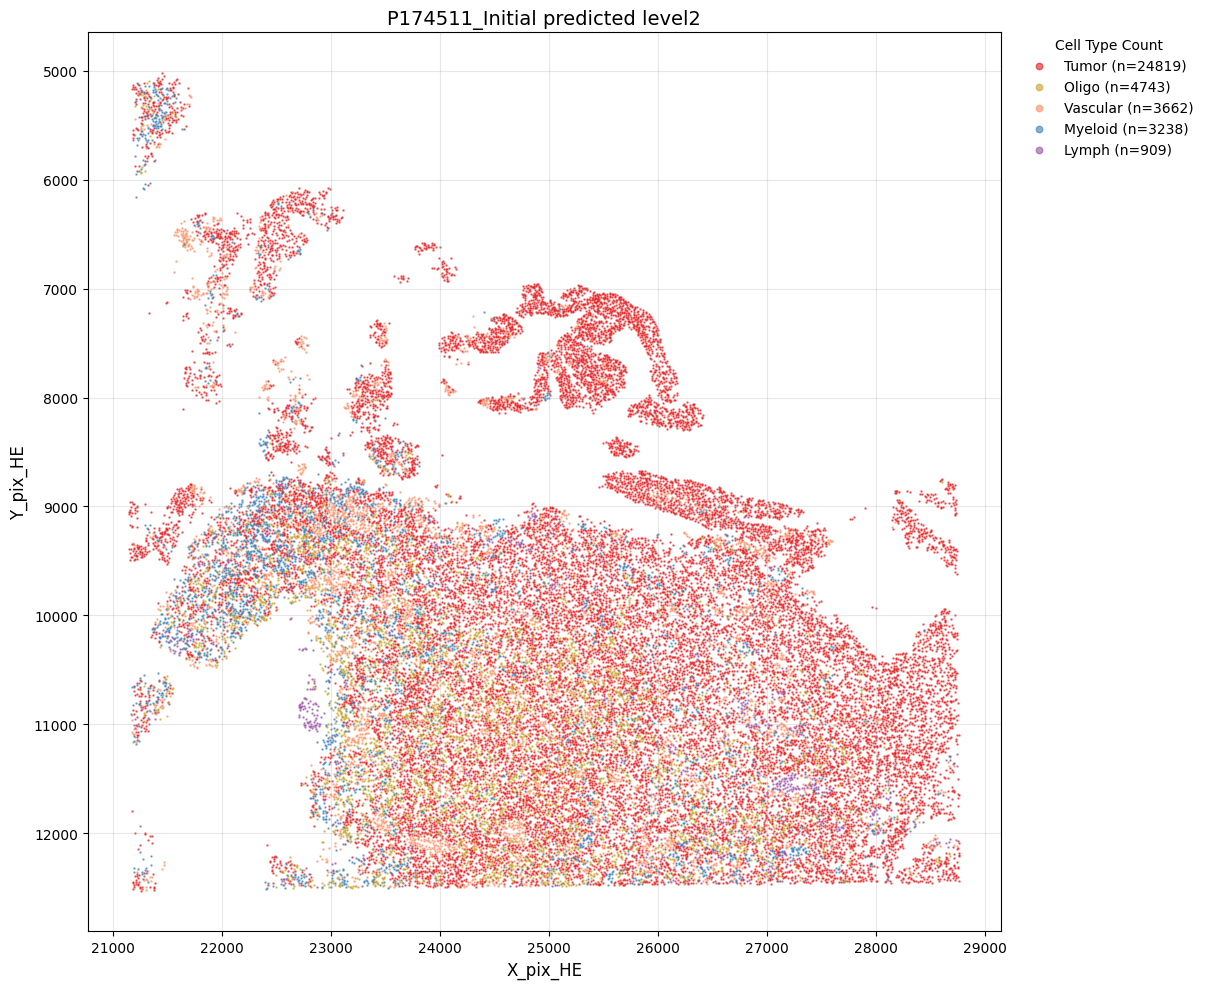


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 37371
Number of cell types: 5


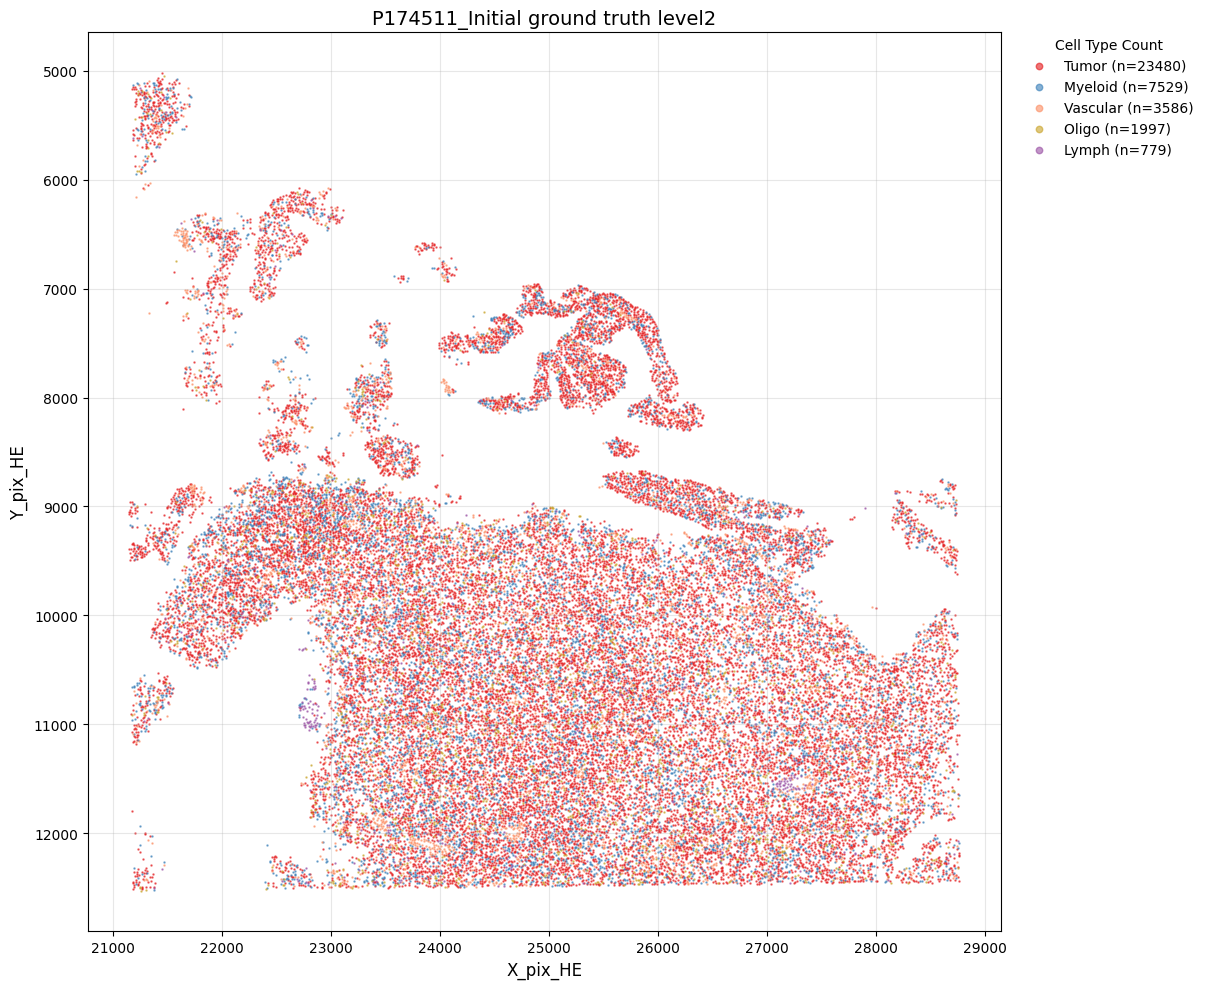

In [16]:
## Evaluate on all data: level2 spatial — predicted vs ground truth
# Rows must match cv_data filter and scaler fit on X_f.
# When use_spatial_context=True, pass neighbor_index from build_spatial_neighbor_index.
_nbr = globals().get("spatial_neighbor_index")
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path="",
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=val_loader if "val_loader" in globals() else None,
    X=cv_data["X_f"],
    y=cv_data["y_f"],
    y_encoded=cv_data["y_encoded_f"],
    X_coords_matched=X_coords_plot if "X_coords_plot" in globals() else None,
    celltype_pred_dir=result_fig("celltype_valid_level2"),
    celltype_true_dir=result_fig("celltype_true_level2"),
    spatial_plot_mode="pred_true_l2",
    pan_organ=PAN_ORGAN,
    spatial_title_pred_l2=f"{therapy_data} predicted level2",
    spatial_title_true_l2=f"{therapy_data} ground truth level2",
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if "celltype_pixel_NCRT_tumor1" in globals() else None,
    neighbor_index=_nbr,
)


Number of valid data points: 37371
Number of cell types: 2


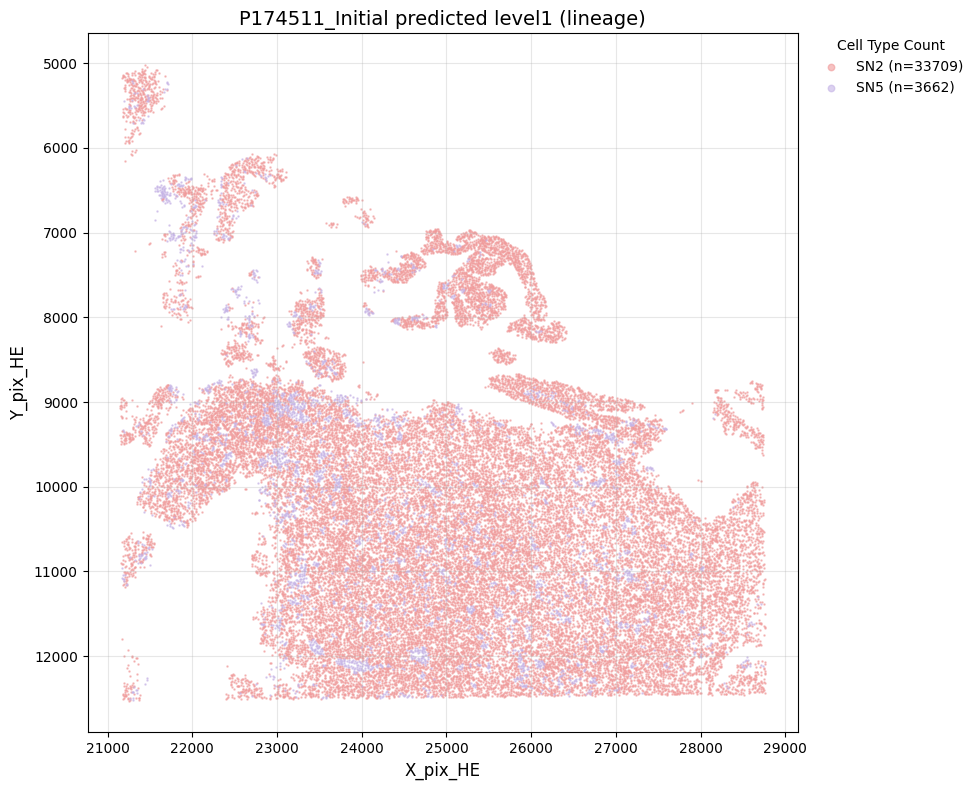

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/celltype_valid_level1.jpg
Number of valid data points: 37371
Number of cell types: 6


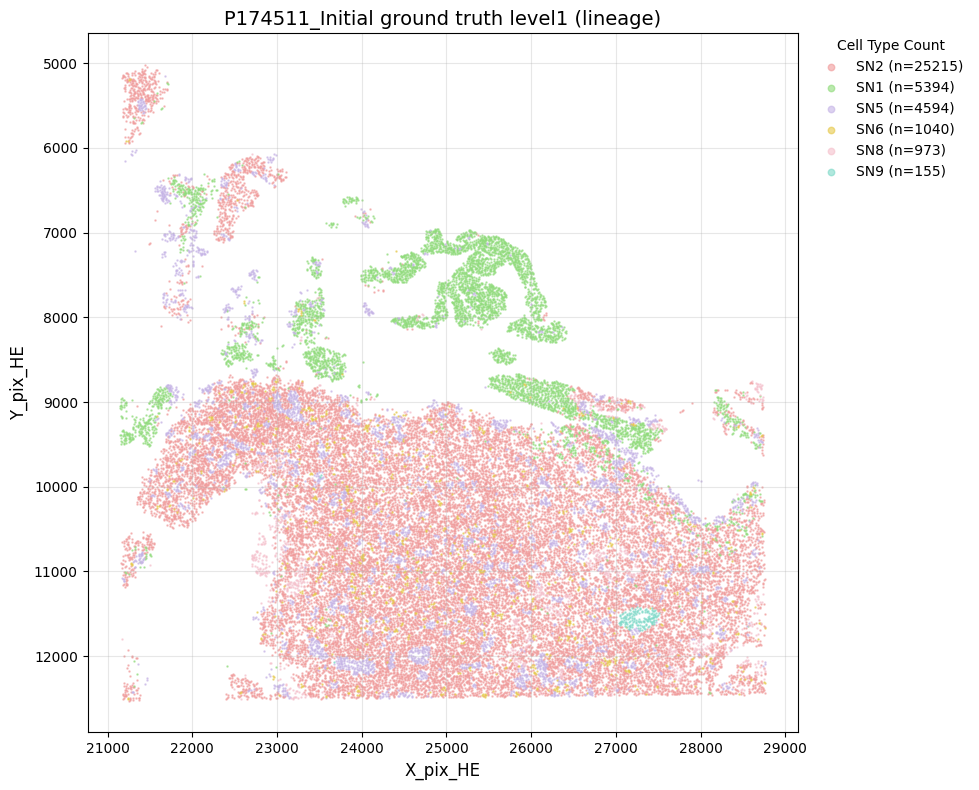

  Saved level1 true spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/celltype_true_level1.jpg


In [17]:
# Use the registered CODEX GBM coarse palette from the canonical package.
plot_level1_spatial_distribution(
    matched_features_path=matched_features_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=result_fig("celltype_valid_level1"),
    save_path_true=result_fig("celltype_true_level1"),
    pan_organ=PAN_ORGAN,
    title_pred=f"{therapy_data} predicted level1 (lineage)",
    title_true=f"{therapy_data} ground truth level1 (lineage)",
    fig_size=(10, 8),
    show=True,
    X_coords_matched=X_coords_plot if "X_coords_plot" in globals() else None,
    y_level1_f=cv_data["y_level1_f"],
)



L12 sublineage
Number of valid data points: 37371
Number of cell types: 13


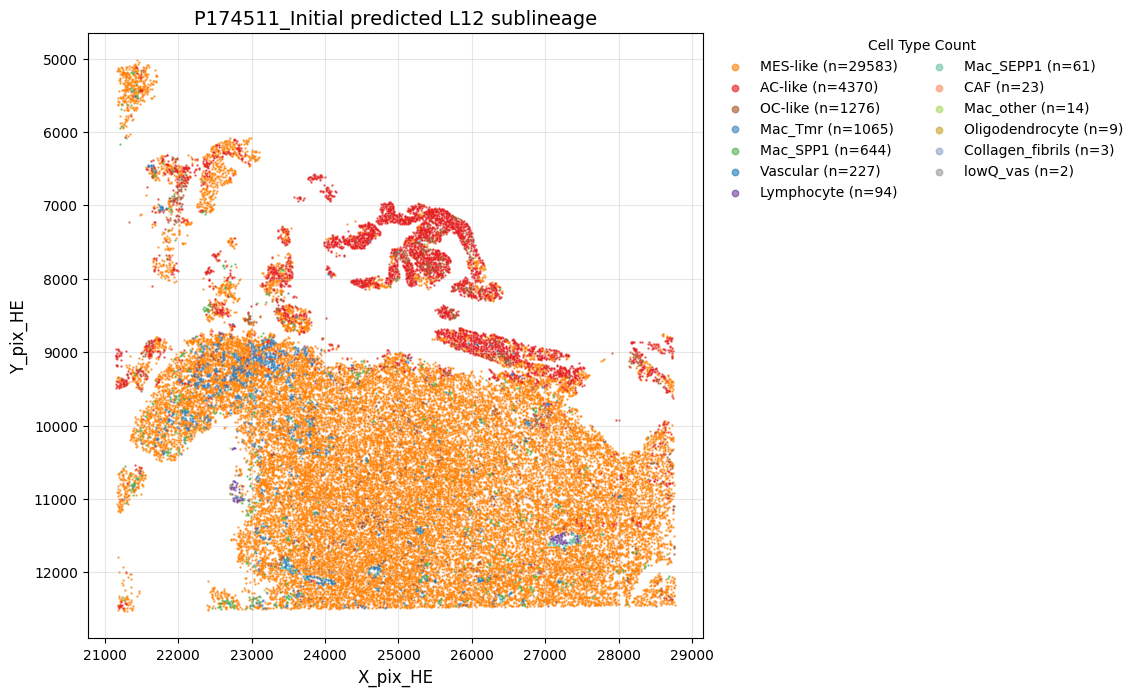

  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/celltype_valid_level12.jpg
Number of valid data points: 37371
Number of cell types: 13


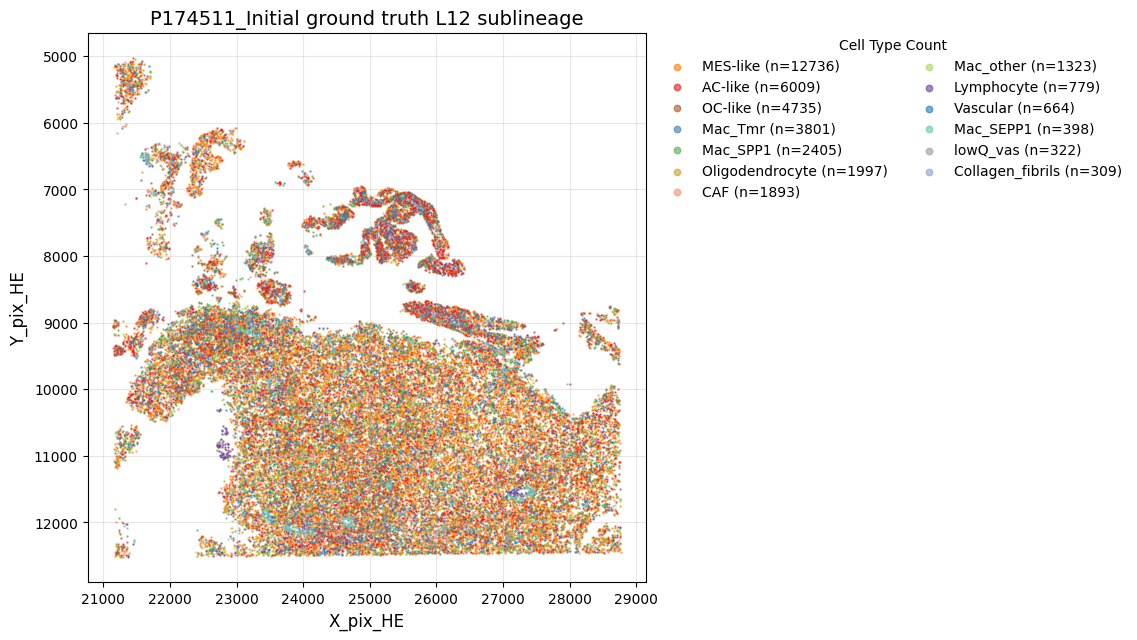

  Saved ground-truth spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/celltype_true_level12.jpg
Skip L3 CNiche spatial: no val_preds_level3
Skip L4 TNiche spatial: no val_preds_level4


In [18]:
## L12 intermediate hierarchy spatial — predicted vs ground truth
if isinstance(globals().get("LP"), dict) and LP.get("model") is not None:
    ensure_lp_extra_insample_preds(
        LP["model"],
        scaler,
        cv_data,
        device,
        predict_all_label_heads,
        globals(),
        neighbor_index=globals().get("spatial_neighbor_index"),
    )
plot_he_spatial_extra_tiers(
    plot_tier_spatial_distribution,
    plot_celltype_spatial_distribution,
    result_fig,
    therapy_data,
    X_coords_plot if "X_coords_plot" in globals() else None,
    cv_data if "cv_data" in globals() else None,
    globals(),
    pan_organ=PAN_ORGAN,
)


## Predict StarDist

In [19]:
## Load best model for StarDist prediction.
_star_ckpt = globals().get("BEST_MLP_CHECKPOINT")
if _star_ckpt is None and isinstance(globals().get("LP"), dict):
    _bf = LP.get("best_fold")
    if isinstance(_bf, dict):
        _star_ckpt = _bf.get("checkpoint")
if _star_ckpt is None:
    _cand = BEST_MLP_PATH if "BEST_MLP_PATH" in globals() else get_select4_best_checkpoint_path(path, therapy_data, therapy_model)
    if os.path.isfile(_cand):
        _star_ckpt = _cand

model_star = load_model_for_predict(
    path,
    therapy_data,
    therapy_model,
    parent_dir=True,
    checkpoint_path=_star_ckpt,
    device=device if "device" in globals() else None,
)


Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/best_mlp_gpu.pt
  Inferred hidden_dims from checkpoint: [1024, 512, 256]
✓ StarDist model loaded


In [20]:
## StarDist matched features for CODEX GBM
# StarDist centroids: prepared CSV under data/CODEX/GBM/WangLab/StarDist_Segment only
#   (do not rebuild from ImgEmbeddings_all_stardist/*.pth filenames).
# GT→StarDist cell table is prebuilt by match_codex_cells_with_pixel.py:
#   {SAMPLE_DIR}/{therapy_data}_cells_matched_by_stardist.csv
# This cell only builds matched_features_stardist.h5ad (generate once; reuse when present).

hist_embedding_stardist_dir = Path(f'{MODEL_DIR}/ImgEmbeddings_all_stardist/sc_pth_16_16')
stardist_raw_path = Path(globals().get(
    'stardist_raw_path',
    gbm_stardist_csv_path(therapy_data, STARDIST_ROOT),
))
if not stardist_raw_path.is_file():
    raise FileNotFoundError(
        "Prepared StarDist CSV not found under StarDist_Segment.\n"
        f"Expected: {stardist_raw_path}"
    )
print('stardist_raw_path =', stardist_raw_path)

celltype_pixel_stardist_path = globals().get(
    'celltype_pixel_stardist_path',
    f'{SAMPLE_DIR}/{therapy_data}_cells_matched_by_stardist.csv',
)
matched_features_stardist_path = f'{SAMPLE_DIR}/{therapy_data}_matched_features_stardist.h5ad'
pth_prefix_stardist = f'sc_{therapy_data}'  # StarDist UNI files use HE key, not acq_id

if not Path(celltype_pixel_stardist_path).is_file():
    raise FileNotFoundError(
        f"Missing preprocessed StarDist-matched table: {celltype_pixel_stardist_path}\n"
        "Run: conda run -n SeededNTM python code/CODEX_gbm/match_codex_cells_with_pixel.py "
        f"--sample {therapy_data}"
    )
print(f'Using preprocessed StarDist-matched cells: {celltype_pixel_stardist_path}')

level1_name = globals().get('level1_name', 'celltype_level1')
_column_rename = globals().get('column_rename', {
    'final_CT': 'celltype',
    'final_sublineage': 'celltype_level12',
    'final_lineage': 'celltype_level1',
})
match_tolerance = 1.0

# Build StarDist matched h5ad once. Set True only after changing CSV / embeddings.
FORCE_REBUILD_STARDIST_H5AD = False
if not Path(matched_features_stardist_path).is_file():
    FORCE_REBUILD_STARDIST_H5AD = True
print(f'FORCE_REBUILD_STARDIST_H5AD = {FORCE_REBUILD_STARDIST_H5AD}')

adata_star = match_hist2cell_h5ad(
    cell_coords_path=celltype_pixel_stardist_path,
    hist_embedding_dir=hist_embedding_stardist_dir,
    matched_h5ad_path=matched_features_stardist_path,
    coord_cols=('centroid_x', 'centroid_y'),
    tolerance=match_tolerance,
    pth_prefix=pth_prefix_stardist,
    level1_name=level1_name,
    column_rename=_column_rename,
    auto_rename=False,
    force_rebuild=FORCE_REBUILD_STARDIST_H5AD,
    obs_columns=base.HCC_H5AD_OBS_COLUMNS,
    spatial_cols=('centroid_x', 'centroid_y'),
    spatial_he_cols=('X_pix_HE', 'Y_pix_HE'),
    cell_id_col='cell_id',
)
print(adata_star)
print('obs columns:', list(adata_star.obs.columns))
print('obsm keys:', list(adata_star.obsm.keys()))

# Backward-compatible names for downstream StarDist cells
X_star = adata_X_to_dense(adata_star.X)
y_star = adata_star.obs['final_CT'].to_numpy()
y_star_level1 = adata_star.obs['final_lineage'].to_numpy()
y_star_level12 = adata_star.obs['final_sublineage'].to_numpy()
y_star_level3 = y_star_level4 = None
X_coords_star = adata_star.obsm['spatial']

# StarDist spatial kNN (for models trained with use_spatial_context)
spatial_neighbor_index_star = None
if use_spatial_context:
    spatial_neighbor_index_star = build_spatial_neighbor_index(
        np.asarray(X_coords_star), k_neighbors=spatial_k
    )
    print(
        f"StarDist spatial context: k={spatial_k}, mode={spatial_mode!r}, "
        f"neighbor_index shape={spatial_neighbor_index_star.shape}"
    )


stardist_raw_path = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/WangLab/StarDist_Segment/174511-2-3/174511-2-3_Float_prob0.01_nms_0.3.csv
Using preprocessed StarDist-matched cells: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_cells_matched_by_stardist.csv
FORCE_REBUILD_STARDIST_H5AD = False
  ✓ matched h5ad cache found; loading /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_matched_features_stardist.h5ad
  ✓ Loaded h5ad: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_matched_features_stardist.h5ad (15,473 cells × 1024 features)
AnnData object with n_obs × n_vars = 15473 × 1024
    obs: 'final_CT', 'final_lineage', 'final_sublineage', 'tma', 'cell_id', 'cell_type', 'subcluster', 'spatial_niche', 'bin_barcode'
    uns: 'cell_coords_path', 'embedding_dim', 'embedding_dir', 'match_rate', 'match_tolerance', 'matched_n_cells', 'pth_prefix', 'raw_n_cells', 'so

  Spatial inference: enabled (neighbor_index shape=(15473, 8))
  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_matched_features_stardist.h5ad: (15473, 1024)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_matched_features_stardist.h5ad: (15473,), dtype: object
  ⚠ prediction_only=True: Labels will be used for visualization only, not for evaluation.
  ✓ Keeping labels as strings for visualization (no encoding needed)
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (15473, 1024)
  No labels available - prediction mode only
X_all_scaled:  (15473, 1024)
dummy_labels:  (15473,)
  Total samples: 15473
  DataLoader batch_size: 1024, num_workers: 4
  Predicting on new data (no labels for evaluation)...


Predicting: 100%|██████████| 16/16 [00:00<00:00, 25.74it/s]



Prediction completed:
  Total predictions: 15473
  Predicted classes: [0 1 2 3 4]
  ✓ Using original labels for visualization: 15473 labels
  ✓ Computed metrics in prediction_only mode from aligned true labels: acc=0.5519, macro_f1=0.3149, weighted_f1=0.5440

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/P174511_Initial_matched_features_stardist.h5ad: (15473, 2)
  Coordinates shape: (15473, 2)
  Predictions shape: (15473,)
  ✓ Created prediction DataFrame with 15473 cells

Plotting spatial distribution of PREDICTED level2 cell types...
Number of valid data points: 15473
Number of cell types: 5


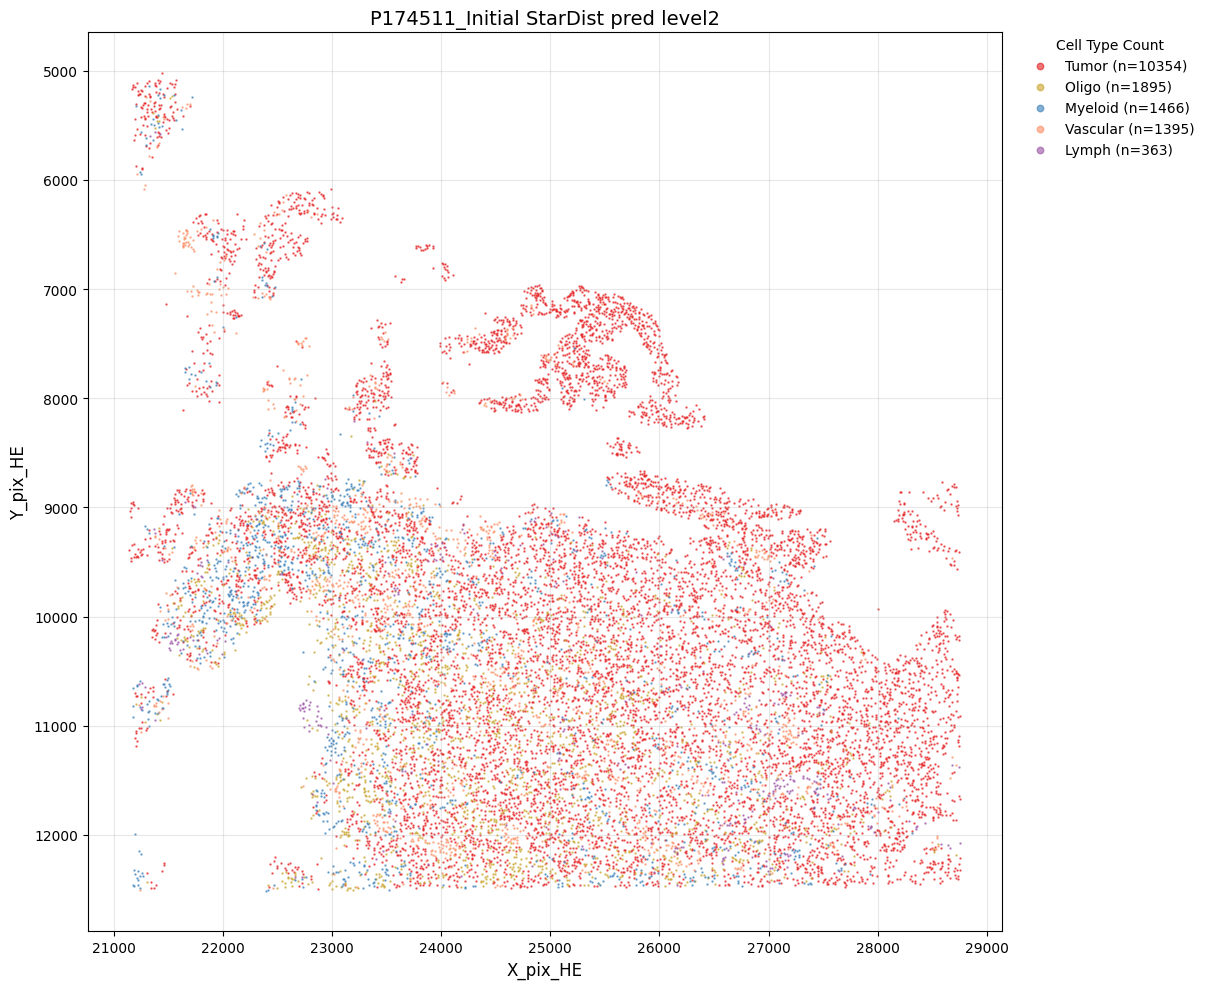


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 15473
Number of cell types: 5


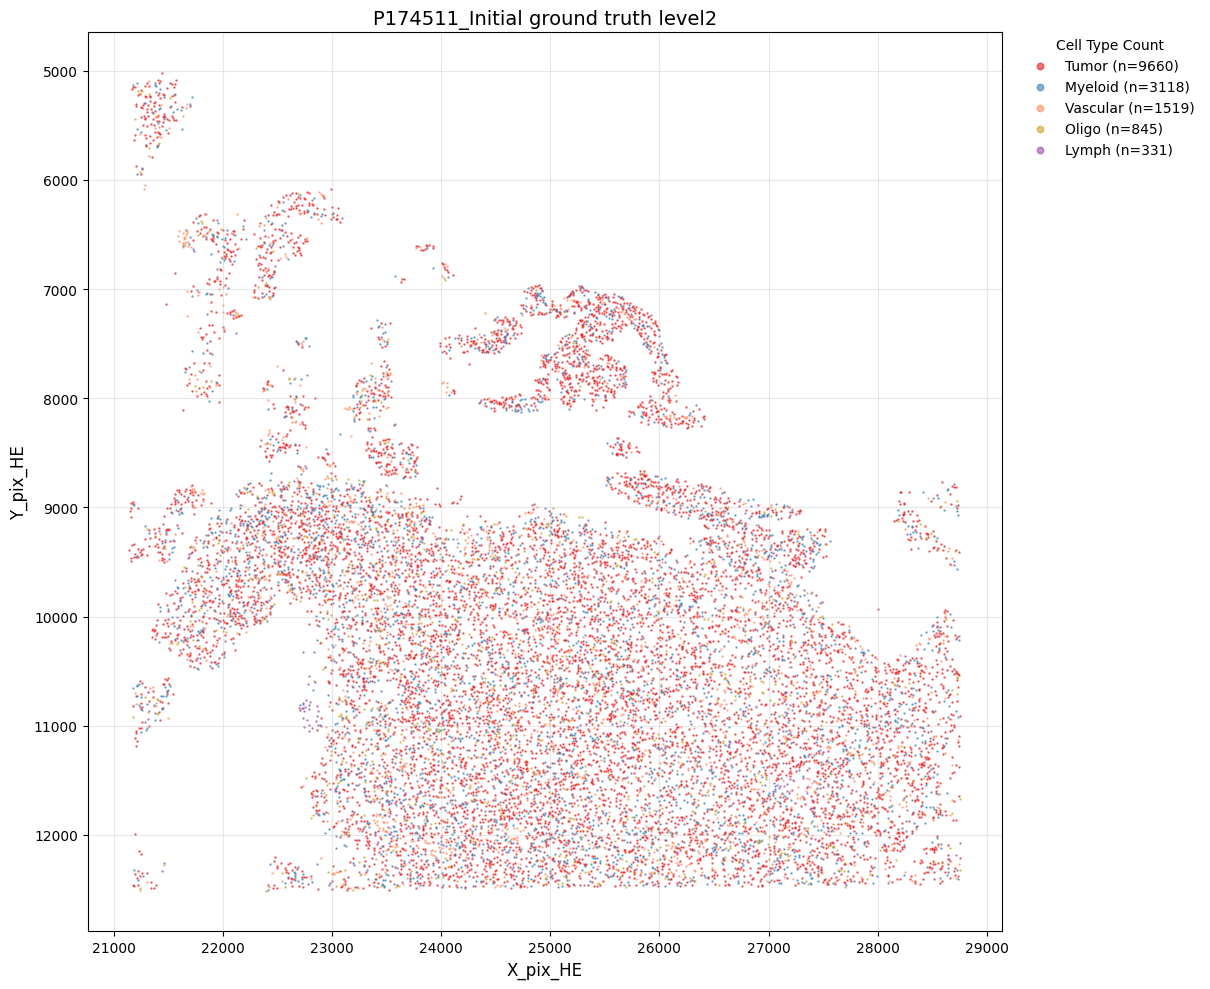

In [21]:
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

_nbr_star = globals().get("spatial_neighbor_index_star")
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model_star,
    matched_features_path=matched_features_stardist_path,
    class_names=class_names_star,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=None,
    prediction_only=True,
    X_coords_matched=X_coords_star if "X_coords_star" in globals() else None,
    y_level1_f=y_star_level1 if "y_star_level1" in globals() else None,
    celltype_pred_dir=result_fig("stardist_pred_level2"),
    # celltype_true_dir=result_fig("stardist_true_level2"),
    spatial_plot_mode="pred_true_l2",
    pan_organ=PAN_ORGAN,
    spatial_title_pred_l2=f"{therapy_data} StarDist pred level2",
    spatial_title_true_l2=f"{therapy_data} ground truth level2",
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if "celltype_pixel_NCRT_tumor1" in globals() else None,
    neighbor_index=_nbr_star,
)


Number of valid data points: 15473
Number of cell types: 2


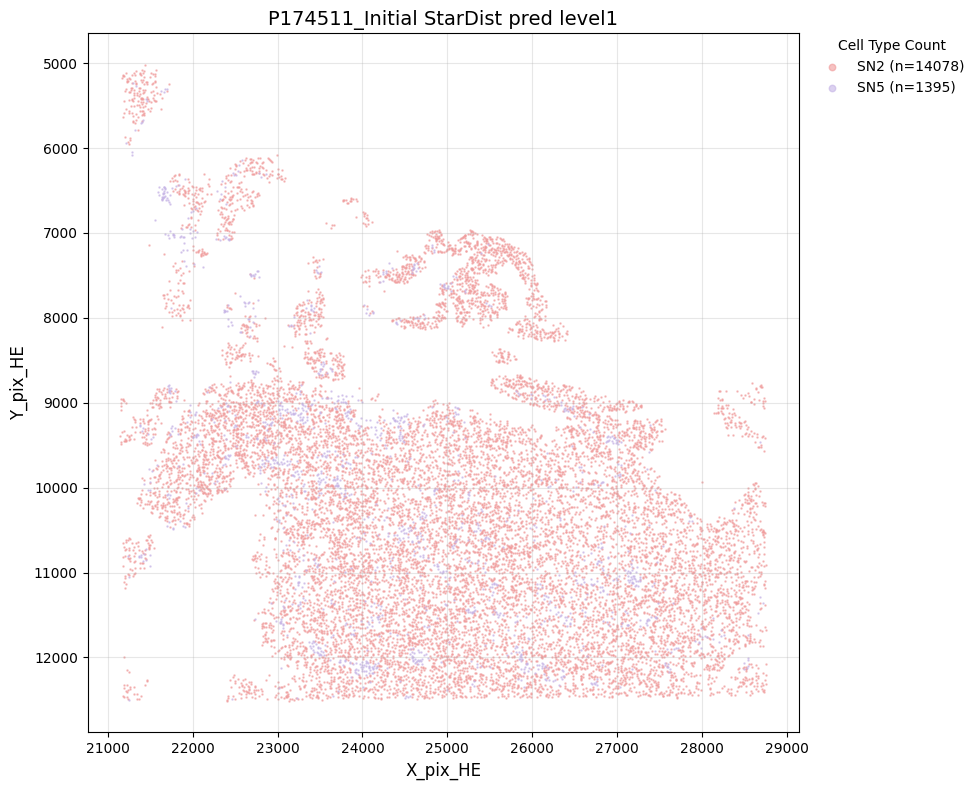

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/celltype_pred_stardist_level1.jpg
Number of valid data points: 15473
Number of cell types: 6


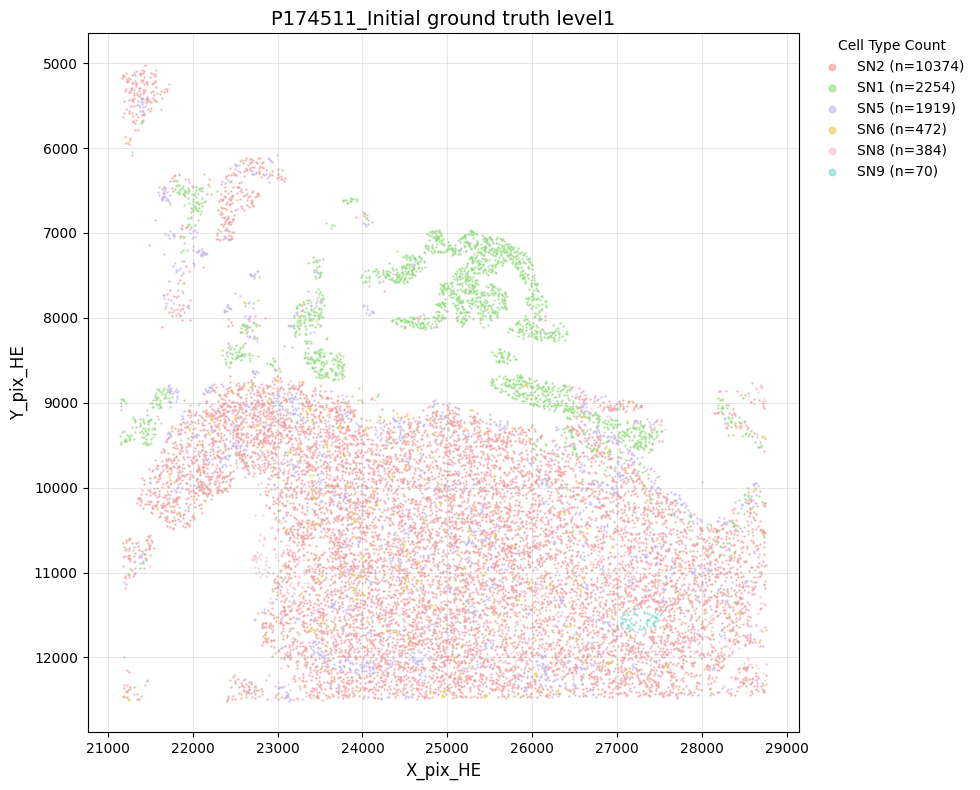

Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/celltype_pred_stardist_level1.jpg


In [22]:
# L2→L1 mapping comes from HE cv_data (same class_names / le_* as the trained model).
# Do not le_level2.transform(y_star): StarDist matched cells can include CT labels absent from training.
# Keep the StarDist plot aligned with the registered CODEX GBM coarse palette.
plot_level1_spatial_distribution(
    matched_features_path=matched_features_stardist_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=result_fig("stardist_pred_level1"),
    # save_path_true=result_fig("stardist_true_level1"),
    pan_organ=PAN_ORGAN,
    fig_size=(10, 8),
    show=True,
    X_coords_matched=X_coords_star,
    y_level1_f=y_star_level1,
    spatial_title_pred_l1=f"{therapy_data} StarDist pred level1",
    spatial_title_true_l1=f"{therapy_data} ground truth level1",
)
print(f"Saved: {result_fig('stardist_pred_level1')}")



L12 sublineage (StarDist)
Number of valid data points: 15473
Number of cell types: 11


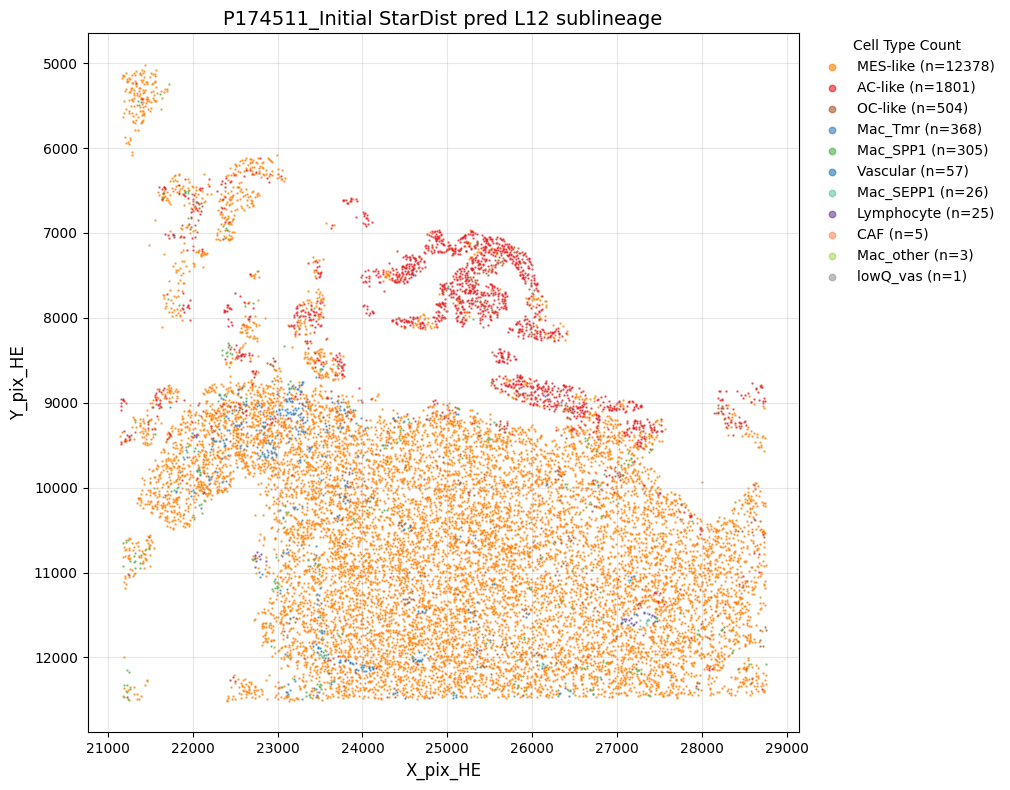

  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/celltype_pred_stardist_level12.jpg
Number of valid data points: 15473
Number of cell types: 13


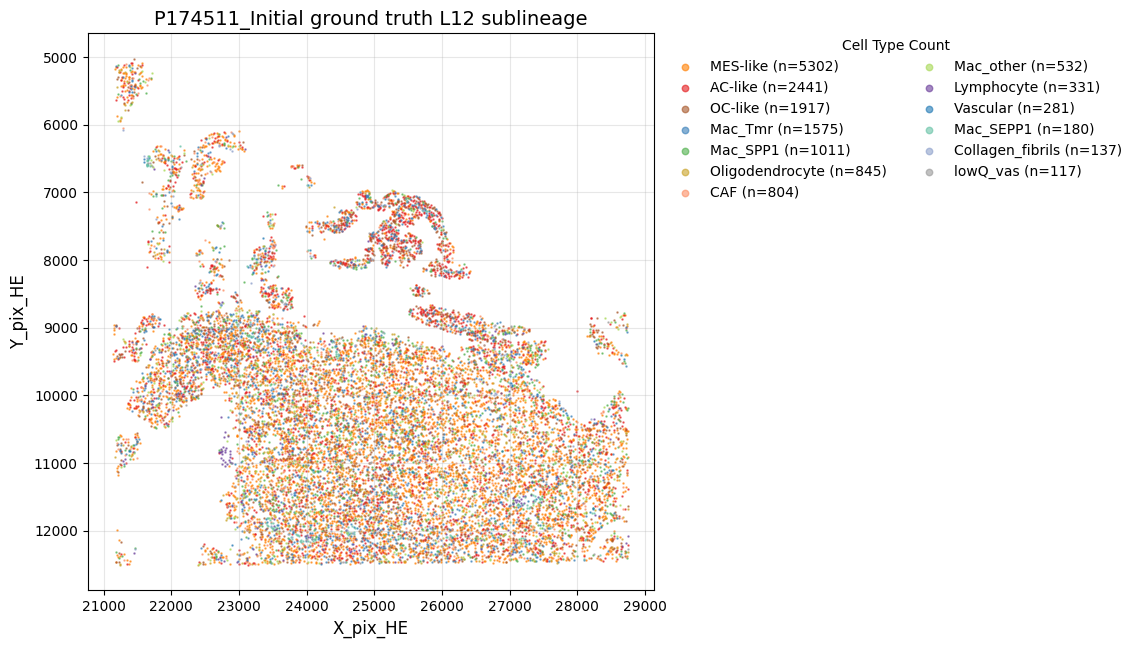

  Saved ground-truth spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/celltype_true_stardist_level12.jpg
Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/celltype_pred_stardist_level12.jpg
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4


In [23]:
## StarDist: L12 intermediate hierarchy spatial — predicted vs ground truth
if not hasattr(model_star, "level12_head"):
    print("Skip StarDist L12/L3/L4 spatial: model_star is not five-head / three-head.")
else:
    _star_heads = stardist_head_preds(
        model_star,
        scaler,
        X_star,
        device,
        predict_all_label_heads,
        neighbor_index=globals().get("spatial_neighbor_index_star"),
    )
    plot_stardist_spatial_extra(
        plot_tier_spatial_distribution,
        plot_celltype_spatial_distribution,
        result_fig,
        therapy_data,
        X_coords_star,
        _star_heads,
        cv_data if "cv_data" in globals() else None,
        globals(),
        pan_organ=PAN_ORGAN,
    )


Visualizing per-class accuracy...
  ✓ Computed metrics for 5 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/acc_level2_stardist.pdf


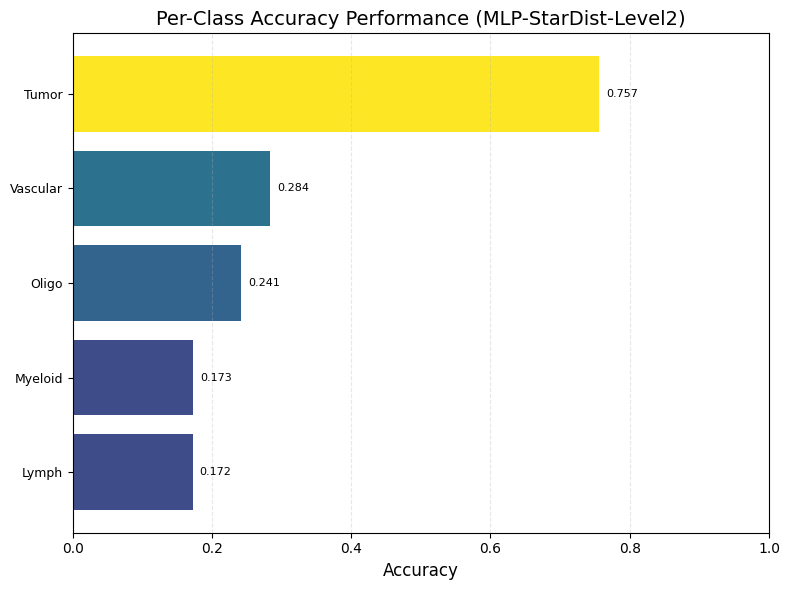


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 5
  Actual classes in test set: 5
  Model parameters: 2,765,080
  Test Accuracy: 0.5519
  Test Macro F1: 0.3149
  Test Weighted F1: 0.5440
Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/acc_level2_stardist.pdf
  Level1 metrics from level2 preds: acc=0.6704, macro_f1=0.1898, weighted_f1=0.5800
Visualizing per-class accuracy...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/acc_level1_stardist.pdf


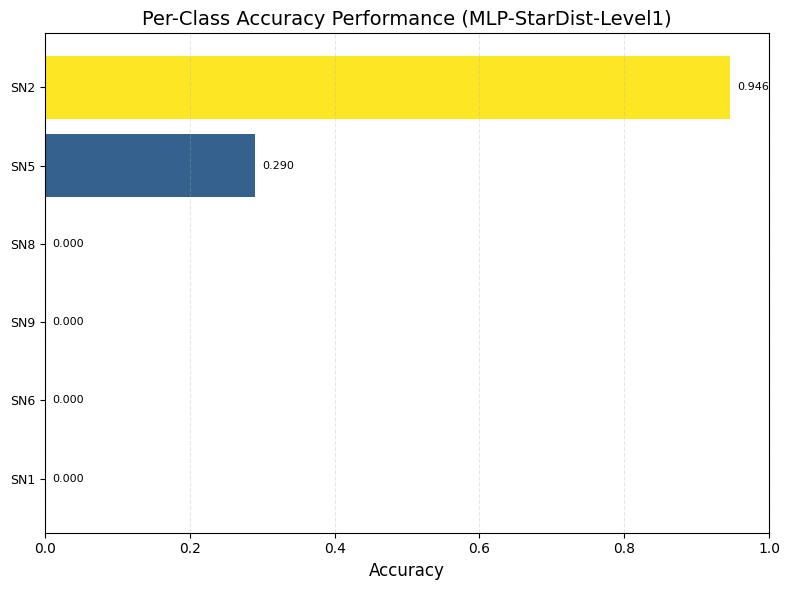


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Model parameters: 2,765,080
  Test Accuracy: 0.6704
  Test Macro F1: 0.1898
  Test Weighted F1: 0.5800
Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/acc_level1_stardist.pdf
  Level1 metrics from L1 head: acc=0.4713, macro_f1=0.4100, weighted_f1=0.5129
Visualizing per-class accuracy...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/acc_level1_stardist_L1head.pdf


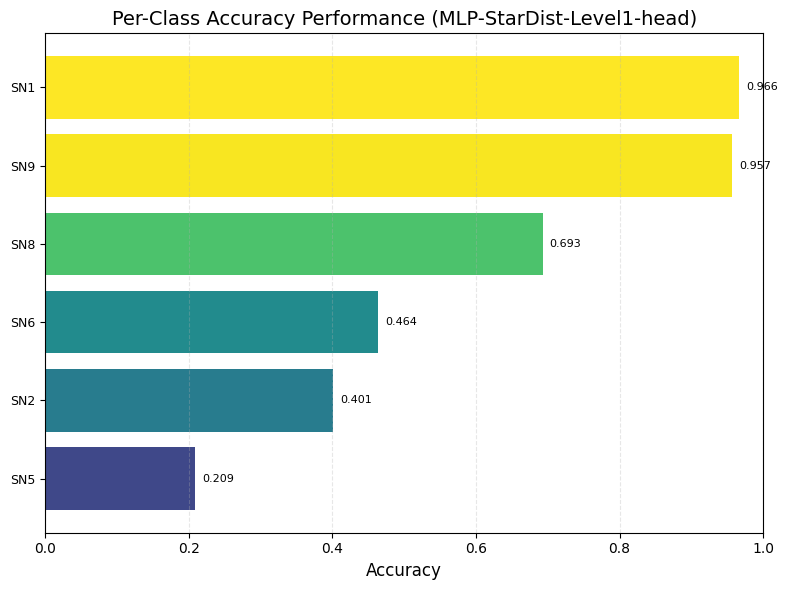


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Model parameters: 2,765,080
  Test Accuracy: 0.4713
  Test Macro F1: 0.4100
  Test Weighted F1: 0.5129
Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/acc_level1_stardist_L1head.pdf

L12 sublineage (StarDist): acc=0.3696, macro_f1=0.1108
Visualizing per-class accuracy...
  ✓ Computed metrics for 13 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/acc_level12_stardist.pdf


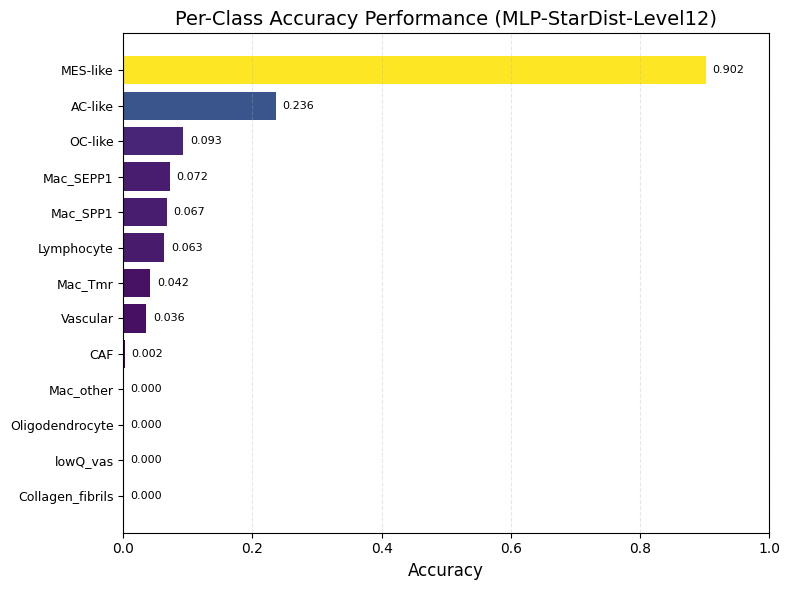


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 13
  Actual classes in test set: 13
  Model parameters: 2,765,080
  Test Accuracy: 0.3696
  Test Macro F1: 0.1108
  Test Weighted F1: 0.2656
Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/acc_level12_stardist.pdf
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4


In [24]:
## StarDist per-class accuracy (run after StarDist evaluate cell)
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

metrics_acc_star = plot_per_class_accuracy(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    model_name="MLP-StarDist-Level2",
    y_sort_by="acc_asc",
    save_path=result_fig("acc_level2_stardist"),
)
print(f"Saved: {result_fig('acc_level2_stardist')}")

metrics_acc_star_l1 = plot_level1_accuracy_from_level2_predictions(
    matched_features_path=matched_features_stardist_path,
    all_preds=all_preds,
    class_names=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_accuracy=plot_per_class_accuracy,
    model=model_star,
    device=device,
    model_name="MLP-StarDist-Level1",
    y_sort_by="acc_asc",
    save_path=result_fig("acc_level1_stardist"),
)
if metrics_acc_star_l1 is not None:
    print(f"Saved: {result_fig('acc_level1_stardist')}")

metrics_acc_star_l1_head = plot_level1_accuracy_from_level1_head(
    matched_features_path=matched_features_stardist_path,
    model=model_star,
    device=device,
    scaler=scaler,
    class_names_level1=class_names_level1,
    plot_per_class_accuracy=plot_per_class_accuracy,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    model_name="MLP-StarDist-Level1-head",
    y_sort_by="acc_asc",
    save_path=result_fig("acc_level1_stardist_L1head"),
    neighbor_index=globals().get("spatial_neighbor_index_star"),
)
if metrics_acc_star_l1_head is not None:
    print(f"Saved: {result_fig('acc_level1_stardist_L1head')}")

if not hasattr(model_star, "level12_head"):
    print("Skip StarDist L12/L3/L4 per-class accuracy: model_star is not five-head / three-head.")
else:
    _star_heads = stardist_head_preds(
        model_star,
        scaler,
        X_star,
        device,
        predict_all_label_heads,
        neighbor_index=globals().get("spatial_neighbor_index_star"),
    )
    plot_stardist_acc_extra(plot_per_class_accuracy, result_fig, model_star, device, _star_heads, cv_data if "cv_data" in globals() else None, globals())


Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/conf_matrix_level2_stardist.pdf


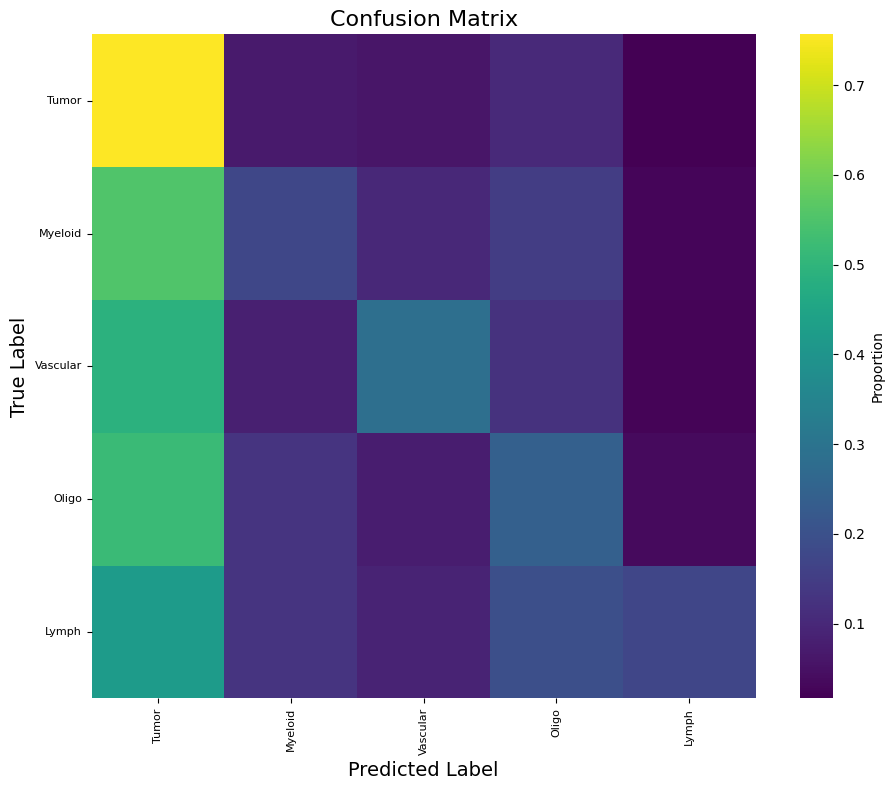

Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/conf_matrix_level1_stardist.pdf


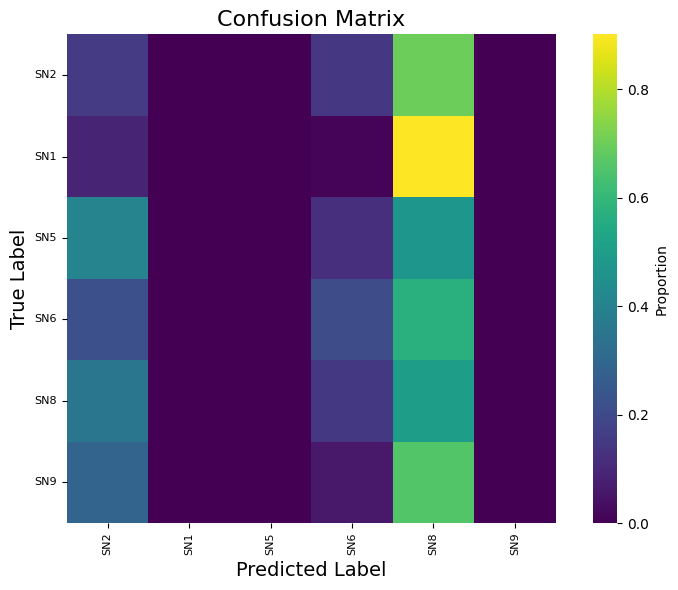


L12 sublineage (StarDist) confusion matrix
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/conf_matrix_level12_stardist.pdf


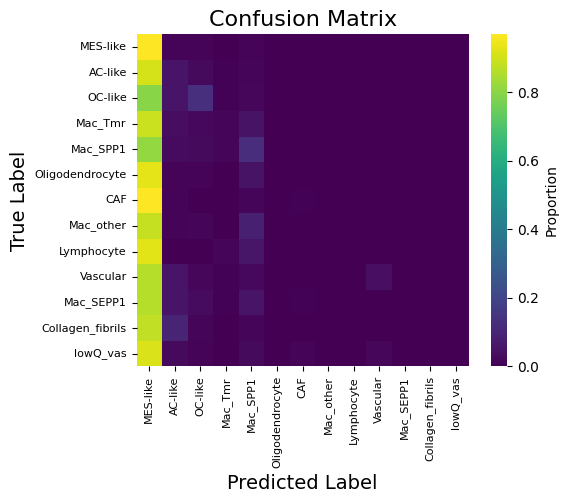

Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/conf_matrix_level12_stardist.pdf
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4


In [25]:
# StarDist prediction heatmaps (confusion matrices): level2 + level1
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

plot_confusion_matrix(
    all_labels,
    all_preds,
    class_names_star,
    figsize=(10, 8),
    save_path=result_fig("conf_matrix_level2_stardist"),
)

_loaded_star = load_matched_features_bundle(matched_features_stardist_path)
if "y_level1" in _loaded_star:
    _preds_arr = np.asarray(all_preds, dtype=np.int64)
    _n = min(len(_preds_arr), len(_loaded_star["y_level1"]))
    _preds_arr = _preds_arr[:_n]
    _y_true_l1_raw = _loaded_star["y_level1"][:_n]
    _l2_ok = (_preds_arr >= 0) & (_preds_arr < len(class_names_star))
    _child_to_parent = np.full(len(class_names_star), -1, dtype=np.int64)
    for _l2, _l1 in zip(y_encoded_f, y_level1_encoded_f):
        _l2_i, _l1_i = int(_l2), int(_l1)
        if _child_to_parent[_l2_i] == -1:
            _child_to_parent[_l2_i] = _l1_i
    _preds_l1 = _child_to_parent[_preds_arr[_l2_ok]]
    _y_true_l1_raw = _y_true_l1_raw[_l2_ok]

    if getattr(_y_true_l1_raw, "dtype", None) is not None and _y_true_l1_raw.dtype.kind in ["U", "S", "O"]:
        _name_to_idx = {str(c): i for i, c in enumerate(class_names_level1)}
        _y_true_l1 = np.array([_name_to_idx.get(str(v), -1) for v in _y_true_l1_raw], dtype=np.int64)
    else:
        _y_true_l1 = np.asarray(_y_true_l1_raw, dtype=np.int64)

    _n = min(len(_y_true_l1), len(_preds_l1))
    _y_true_l1 = _y_true_l1[:_n]
    _preds_l1 = _preds_l1[:_n]
    _valid = _y_true_l1 >= 0

    if np.any(_valid):
        plot_confusion_matrix(
            _y_true_l1[_valid],
            _preds_l1[_valid],
            class_names_level1,
            figsize=(8, 6),
            save_path=result_fig("conf_matrix_level1_stardist"),
            # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level1_stardist_hce.pdf',
        )
    else:
        print("Skip level1 StarDist confusion matrix: no valid y_level1 labels.")
else:
    print(f"Skip level1 StarDist confusion matrix: y_level1 not found in {matched_features_stardist_path}")

if not hasattr(model_star, "level12_head"):
    print("Skip StarDist L12/L3/L4 confusion matrices: model_star is not five-head.")
else:
    _star_heads = stardist_head_preds(model_star, scaler, X_star, device, predict_all_label_heads)
    plot_stardist_confusion_extra(plot_confusion_matrix, result_fig, _star_heads, cv_data if "cv_data" in globals() else None, globals())


Visualizing per-class performance...
  ✓ Computed metrics for 5 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/f1_level2_stardist.pdf


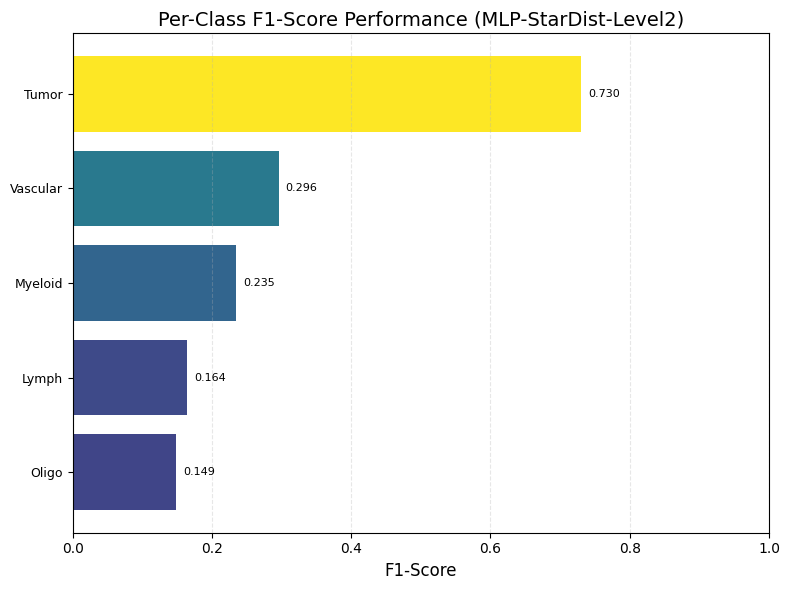


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 5
  Actual classes in test set: 5
  Model parameters: 2,765,080
  Test Accuracy: 0.5519
  Test Macro F1: 0.3149
  Test Weighted F1: 0.5440
  Level1 F1 plot from level2 preds (same mapping as accuracy helper): acc=0.6704, macro_f1=0.1898, weighted_f1=0.5800
Visualizing per-class performance...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/f1_level1_stardist.pdf


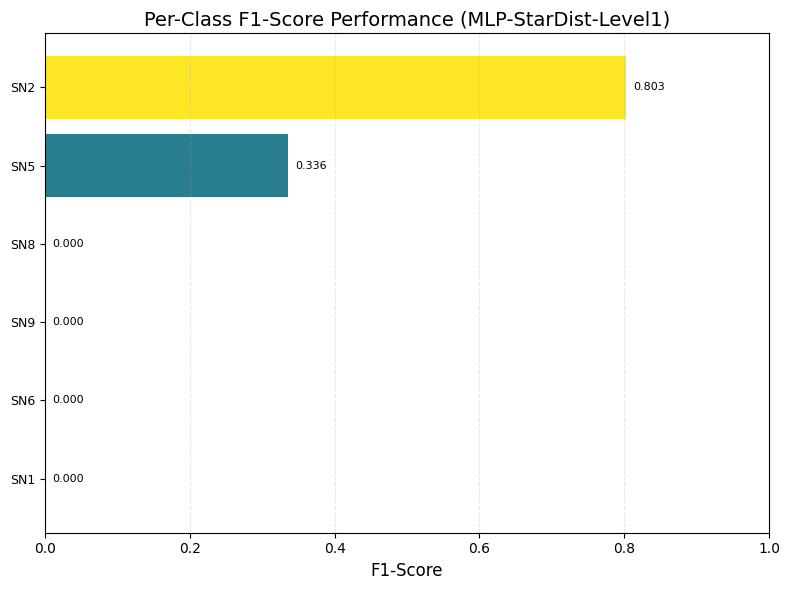


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Model parameters: 2,765,080
  Test Accuracy: 0.6704
  Test Macro F1: 0.1898
  Test Weighted F1: 0.5800
  Level1 F1 plot from L1 head: acc=0.4713, macro_f1=0.4100, weighted_f1=0.5129
Visualizing per-class performance...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/f1_level1_stardist_L1head.pdf


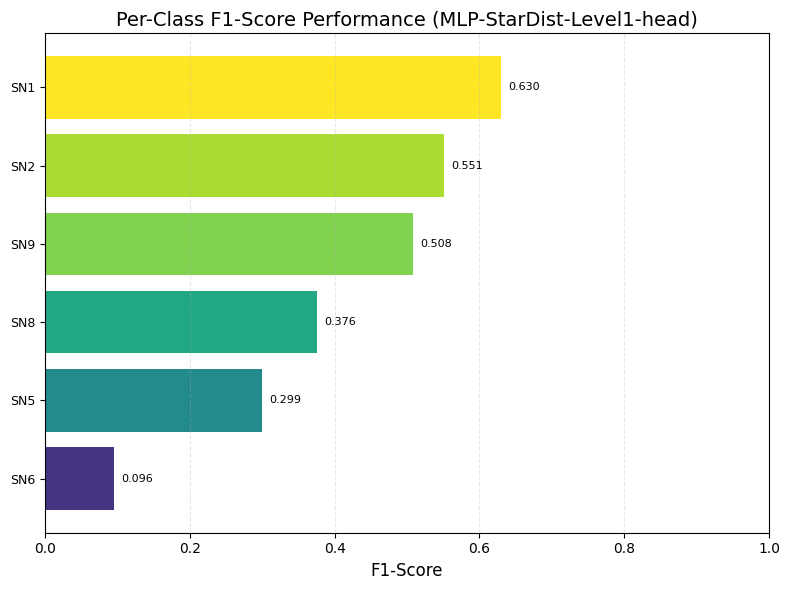


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Model parameters: 2,765,080
  Test Accuracy: 0.4713
  Test Macro F1: 0.4100
  Test Weighted F1: 0.5129

L12 sublineage (StarDist) per-class F1
Visualizing per-class performance...
  ✓ Computed metrics for 13 classes
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/f1_level12_stardist.pdf


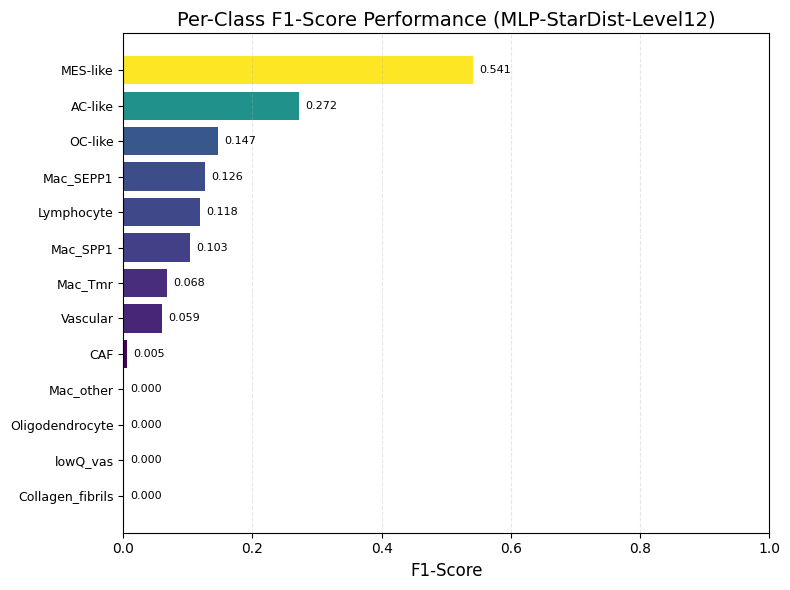


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 13
  Actual classes in test set: 13
  Model parameters: 2,765,080
  Test Accuracy: 0.3696
  Test Macro F1: 0.1108
  Test Weighted F1: 0.2656
Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/f1_level12_stardist.pdf
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4


In [26]:
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

metrics_f1_star = plot_per_class_f1(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    y_sort_by="f1_asc",
    model_name="MLP-StarDist-Level2",
    save_path=result_fig("f1_level2_stardist"),
)

metrics_f1_star_l1 = plot_level1_f1_from_level2_predictions(
    matched_features_path=matched_features_stardist_path,
    all_preds=all_preds,
    class_names=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_f1=plot_per_class_f1,
    model=model_star,
    device=device,
    y_sort_by="f1_asc",
    model_name="MLP-StarDist-Level1",
    save_path=result_fig("f1_level1_stardist"),
)

metrics_f1_star_l1_head = plot_level1_f1_from_level1_head(
    matched_features_path=matched_features_stardist_path,
    model=model_star,
    device=device,
    scaler=scaler,
    class_names_level1=class_names_level1,
    plot_per_class_f1=plot_per_class_f1,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    y_sort_by="f1_asc",
    model_name="MLP-StarDist-Level1-head",
    save_path=result_fig("f1_level1_stardist_L1head"),
    neighbor_index=globals().get("spatial_neighbor_index_star"),
)

if not hasattr(model_star, "level12_head"):
    print("Skip StarDist L12/L3/L4 per-class F1: model_star is not five-head / three-head.")
else:
    _star_heads = stardist_head_preds(
        model_star,
        scaler,
        X_star,
        device,
        predict_all_label_heads,
        neighbor_index=globals().get("spatial_neighbor_index_star"),
    )
    plot_stardist_f1_extra(plot_per_class_f1, result_fig, model_star, device, _star_heads, cv_data if "cv_data" in globals() else None, globals())


  ROC colors: codex_gbm_fine (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/roc_stardist_level2.pdf


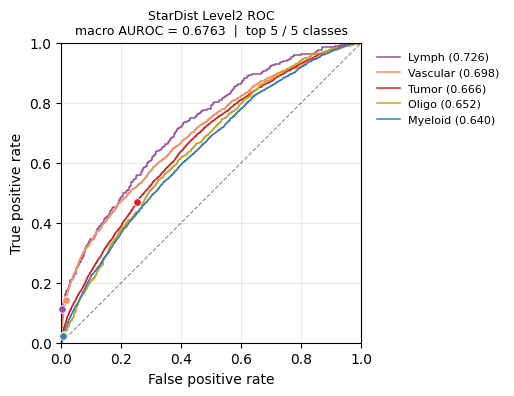

  ROC colors: codex_gbm_coarse (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/roc_stardist_level1.pdf


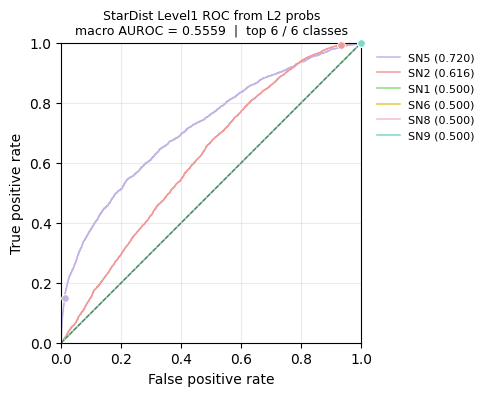

  ROC colors: codex_gbm_coarse (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/roc_stardist_level1_L1head.pdf


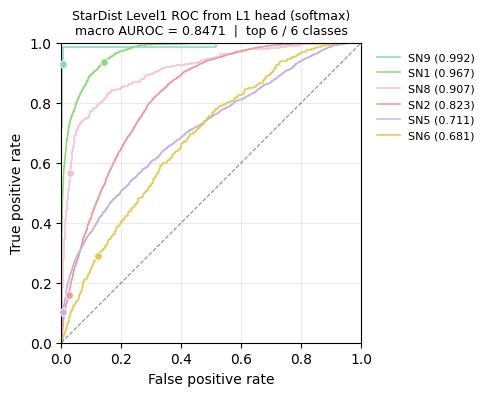


L12 sublineage (StarDist) ROC
  ROC colors: codex_gbm_intermediate (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/roc_stardist_level12.pdf


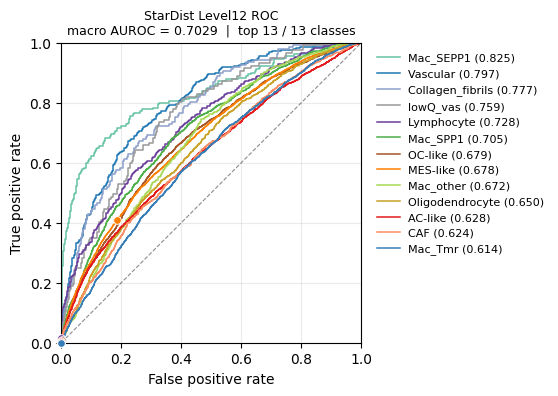

Saved: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initial/project_all_UNI/result/roc_stardist_level12.pdf
Skip L3 CNiche ROC: missing probs l3
Skip L4 TNiche ROC: missing probs l4


In [27]:
import numpy as np

class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

_z = load_matched_features_bundle(matched_features_stardist_path)
X_star_scaled = scaler.transform(_z["X"])
_nbr_star = globals().get("spatial_neighbor_index_star")
probs_l2 = mlp_collect_softmax_probs(
    model_star, X_star_scaled, device, neighbor_index=_nbr_star
)

# Full-length five-head softmax for metrics CSV (ROC plots use valid subset below).
_probs_heads = None
if hasattr(model_star, "level12_head"):
    _probs_heads = mlp_collect_five_head_softmax_probs(
        model_star, X_star_scaled, device, neighbor_index=_nbr_star
    )

# Encode y from the same bundle as probs (training class_names indices; unknown CT → -1).
if "y" not in _z:
    print("Skip ROC: no y in matched features bundle.")
else:
    y_roc = encode_labels_with_class_names(_z["y"], class_names_star)
    m = min(len(probs_l2), len(y_roc))
    probs_m = probs_l2[:m]
    y_m = y_roc[:m]
    valid = (y_m >= 0) & (y_m < len(class_names_star))
    n_bad = int((~valid).sum())
    if n_bad:
        print(
            f"  Excluding {n_bad} StarDist cells whose final_CT is absent from "
            f"training class_names ({len(class_names_star)} classes) for ROC."
        )
    if not np.any(valid):
        print("Skip ROC: no valid training-aligned labels.")
    else:
        _y_l1_roc = _z["y_level1"][:m][valid] if "y_level1" in _z else None
        _X_roc = X_star_scaled[:m][valid]
        _probs_roc = probs_m[valid]
        _y_roc = y_m[valid]

        roc_info_l2 = plot_multiclass_roc_curves(
            _y_roc,
            _probs_roc,
            class_names_star,
            figsize=(3.0, 3.0),
            max_curves=len(class_names_star),
            save_path=result_fig("roc_stardist_level2"),
            title="StarDist Level2 ROC",
            pan_organ=PAN_ORGAN,
        )
        roc_info_l1 = plot_level1_roc_from_level2_scores(
            matched_features_stardist_path,
            _probs_roc,
            class_names_star,
            class_names_level1,
            y_encoded_f,
            y_level1_encoded_f,
            figsize=(3.0, 3.0),
            save_path=result_fig("roc_stardist_level1"),
            title="StarDist Level1 ROC from L2 probs",
            pan_organ=PAN_ORGAN,
            y_level1_f=_y_l1_roc,
        )

        roc_info_l1_head = plot_level1_roc_from_level1_head(
            matched_features_stardist_path,
            model_star,
            device,
            scaler,
            class_names_level1,
            figsize=(3.0, 3.0),
            save_path=result_fig("roc_stardist_level1_L1head"),
            title="StarDist Level1 ROC from L1 head (softmax)",
            pan_organ=PAN_ORGAN,
            X_f=_X_roc,
            y_level1_f=_y_l1_roc,
            neighbor_index=_nbr_star,
        )
        if hasattr(model_star, "level12_head"):
            _probs_heads_roc = {k: v[:m][valid] for k, v in _probs_heads.items()}
            plot_stardist_roc_extra(
                plot_multiclass_roc_curves,
                result_fig,
                _probs_heads_roc,
                cv_data if "cv_data" in globals() else None,
                len(_y_roc),
                globals(),
                pan_organ=PAN_ORGAN,
            )
        else:
            print("Skip StarDist L12/L3/L4 ROC: model_star is not five-head.")


In [28]:
## Save StarDist external validation metrics (matched h5ad; mirrors validation_internal_metrics.csv)
import importlib
import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)
from uni_label_cv_helpers import (
    save_stardist_external_validation_metrics,
    plot_stardist_roc_from_auroc_csv,
    _auroc_csv_path_from_metrics,
)

class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

if "all_preds" not in globals() or "matched_features_stardist_path" not in globals():
    raise NameError("Run StarDist evaluate / per-class accuracy cells first.")

logo_summary = globals().get("logo_summary")
if logo_summary is None and isinstance(globals().get("LP"), dict):
    logo_summary = LP.get("logo_summary")

# Reuse ROC softmax if the ROC cell ran first (avoids a second forward pass).
_probs_l2 = globals().get("probs_l2")
_head_probs = globals().get("_probs_heads")

metrics_df, combined_df, tier_aucs = save_stardist_external_validation_metrics(
    all_labels=all_labels,
    all_preds=all_preds,
    matched_features_path=matched_features_stardist_path,
    class_names_star=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    therapy_data=therapy_data,
    metrics_csv_path=result_fig("validation_external_stardist_matched_metrics"),
    model_star=model_star if "model_star" in globals() else None,
    scaler=scaler,
    X_star=X_star if "X_star" in globals() else None,
    device=device,
    predict_all_label_heads=predict_all_label_heads,
    cv_data=cv_data if "cv_data" in globals() else None,
    g=globals(),
    logo_summary=logo_summary,
    hce_w1=globals().get("hce_w1", 1.0),
    hce_w2=globals().get("hce_w2", 1.0),
    hce_w12=globals().get("hce_w12", 2.0),
    hce_w_l12head=globals().get("hce_w_l12head", 1.0),
    hce_w_l3=globals().get("hce_w_l3", 1.0),
    hce_w_l4=globals().get("hce_w_l4", 1.0),
    probs_l2=_probs_l2,
    head_probs=_head_probs,
)

print("\nStarDist matched per-tier columns (insample_* = StarDist-matched cells, best-fold model):")
_tier_cols = [
    c for c in combined_df.columns
    if c.startswith(("insample_", "num_", "val_")) and ("auc" in c or not c.endswith("_std"))
]
print(combined_df[_tier_cols].tail(1).T)
print("\nMacro AUROC by tier:")
for _t, _v in sorted(tier_aucs.items()):
    print(f"  {_t}: {_v:.4f}")

_auroc_csv = _auroc_csv_path_from_metrics(result_fig("validation_external_stardist_matched_metrics"))
print(f"\nLevel2 AUROC table: {_auroc_csv}")


Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4
Current run metrics:
             timestamp                      therapy_data  best_epoch  \
0  2026-09-08 23:53:47  P174511_Initial_stardist_matched           0   

  hce_lambda  hce_w1  hce_w2  hce_w12  hce_w_l12head  hce_w_l3  hce_w_l4  ...  \
0       None     1.0     2.0      1.0            1.0       1.0       1.0  ...   

   insample_l12_macro_f1  insample_l12_weighted_f1  num_l1_head_classes  \
0               0.084647                  0.237208                    6   

   num_l12_classes  insample_l2_macro_auc  insample_l1_macro_auc  \
0               13               0.676345               0.555894   

   insample_l1_head_macro_auc  insample_l12_macro_auc  val_l2_macro_auc  \
0                     0.84711                0.702903          0.676345   

   val_l1_macro_auc  
0          0.555894  

[1 rows x 38 columns]

Saved comparison table to: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Cases/P174511_Initia

In [29]:
# # Replay Level2 ROC from validation_external_stardist_matched_AUROC.csv
# import importlib
# import uni_label_cv_helpers as uni_nb
# importlib.reload(uni_nb)
# from pathlib import Path
# from uni_label_cv_helpers import plot_stardist_roc_from_auroc_csv, _auroc_csv_path_from_metrics

# class_names_star = globals().get("class_names_star")
# if class_names_star is None:
#     class_names_star = class_names
# _auroc_csv = _auroc_csv_path_from_metrics(
#     result_fig("validation_external_stardist_matched_metrics")
# )
# if not Path(_auroc_csv).is_file():
#     raise FileNotFoundError(f"Run metrics cell first: {_auroc_csv}")

# roc_info_l2_csv = plot_stardist_roc_from_auroc_csv(
#     _auroc_csv,
#     class_names_star,
#     save_path=result_fig("roc_stardist_level2_from_AUROC_csv"),
#     title="StarDist Level2 ROC (from AUROC CSV)",
#     pan_organ=PAN_ORGAN,
# )
# if roc_info_l2_csv:
#     print(f"Macro AUROC from CSV: {roc_info_l2_csv['macro_auc']:.4f}")
